IA & Data science (LU3IN0226) -- 2024-2025
--------
*&copy; Equipe pédagogique: Christophe Marsala, Olivier Schwander, Jean-Noël Vittaut.*


# TD-TME08: arbres de décision numériques, apprentissage non-supervisé

L'objectif de ce TP est d'implémenter des algorithmes d'apprentissage non-supervisé, en particulier, l'algorithme de clutering hiérarchique ascendant.

<font color="RED" size="+1">**[Q]**</font> **Indiquer dans la boîte ci-dessous vos noms et prénoms :**

Ines Harraoui 21204796
Yanis Saadi Dit Saada 21101885

<font color="RED" size="+1"><b>[Q]</b></font> **Renommer ce fichier ipython**

Tout en haut de cette page, cliquer sur <tt>tme-08</tt> et rajouter à la suite de <tt>tme-08</tt> les noms des membres du binômes séparés par un tiret.

<font color="RED" size="+1">IMPORTANT: soumission de votre fichier final</font>

**Nom à donner au fichier à poster** : *tme-08-Nom1_Nom2.ipynb* 
- *Nom1* et *Nom2* : noms des membres du binôme
- ne pas compresser ou faire une archive: il faut rendre le fichier ipython tel quel, éventuellement, si vous avez d'autres fichiers vous les rendez séparément.

**Echancier pour la soumission de votre compte-rendu:**
- le compte-rendu d'une séance doit être remis obligatoirement <font color="RED">avant la séance suivante</font>.

**Le compte-rendu est soumis sur la page Moodle.**


## Préparation

L'archive récupérée avec ce fichier contient aussi le répertoire <code>data</code> qui contient les bases pour expérimenter vos fonctions.

In [1]:
# - - - - - - - - - - - - - - - - - -
# imports utiles
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mtpl
%matplotlib inline  

import math
import time
import sys

# Les instructions suivantes sont utiles pour recharger automatiquement 
# le code modifié dans les librairies externes
%load_ext autoreload
%autoreload 2

# - - - - - - - - - - - - - - - - - -
# Information sur l'environnent utilisé ici:
print("Version python et des librairies:")
print("\tPython ",sys.version)
print("\tpandas: ",pd.__version__)
print("\tnumpy: ",np.__version__)
print("\tmatplotlib: ",mtpl.__version__)

Version python et des librairies:
	Python  3.11.9 (main, Apr 17 2024, 00:00:00) [GCC 13.2.1 20240316 (Red Hat 13.2.1-7)]
	pandas:  1.5.3
	numpy:  1.24.4
	matplotlib:  3.7.4


In [2]:
# Importation de votre librairie iads:
# La ligne suivante permet de préciser le chemin d'accès à la librairie iads
import sys
sys.path.append('../')   # iads doit être dans le répertoire père du répertoire courant !

# Importation de la librairie iads
import iads as iads

# importation de Classifiers
from iads import Classifiers as classif

# importation de utils
from iads import utils as ut

# importation de evaluation
from iads import evaluation as ev



On introduit dans ce TME la librairie Python seaborn (voir: <a href="https://seaborn.pydata.org/">https://seaborn.pydata.org/</a>) qui offre des outils de visualisation assez intéressants. On l'utilise aussi pour accéder à des jeux de données classiques.

In [3]:
# Importation de la librairie seaborn:
import seaborn as sns


In [4]:
print("seaborn: ",sns.__version__)

# Remarque: il n'est pas nécessaire d'avoir exactement cette version-là...

seaborn:  0.13.2


## Arbres de décision numériques

Pour tester la construction d'arbres de décision numériques, on utilise la base des Iris de Fischer (4 variables de description numériques, et 3 valeurs de classes à reconnaître).

In [5]:
# Le dataset des iris est fourni dans le package seaborn, on l'obtient ainsi:
iris_df = sns.load_dataset('iris')

# Contenu du dataframe :
iris_df

# Remarque: dans ce dataframe, la colonne "species" est la colonne de la classe. 
# C'est la seule colonne qui ne contient pas de valeurs réelles.

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


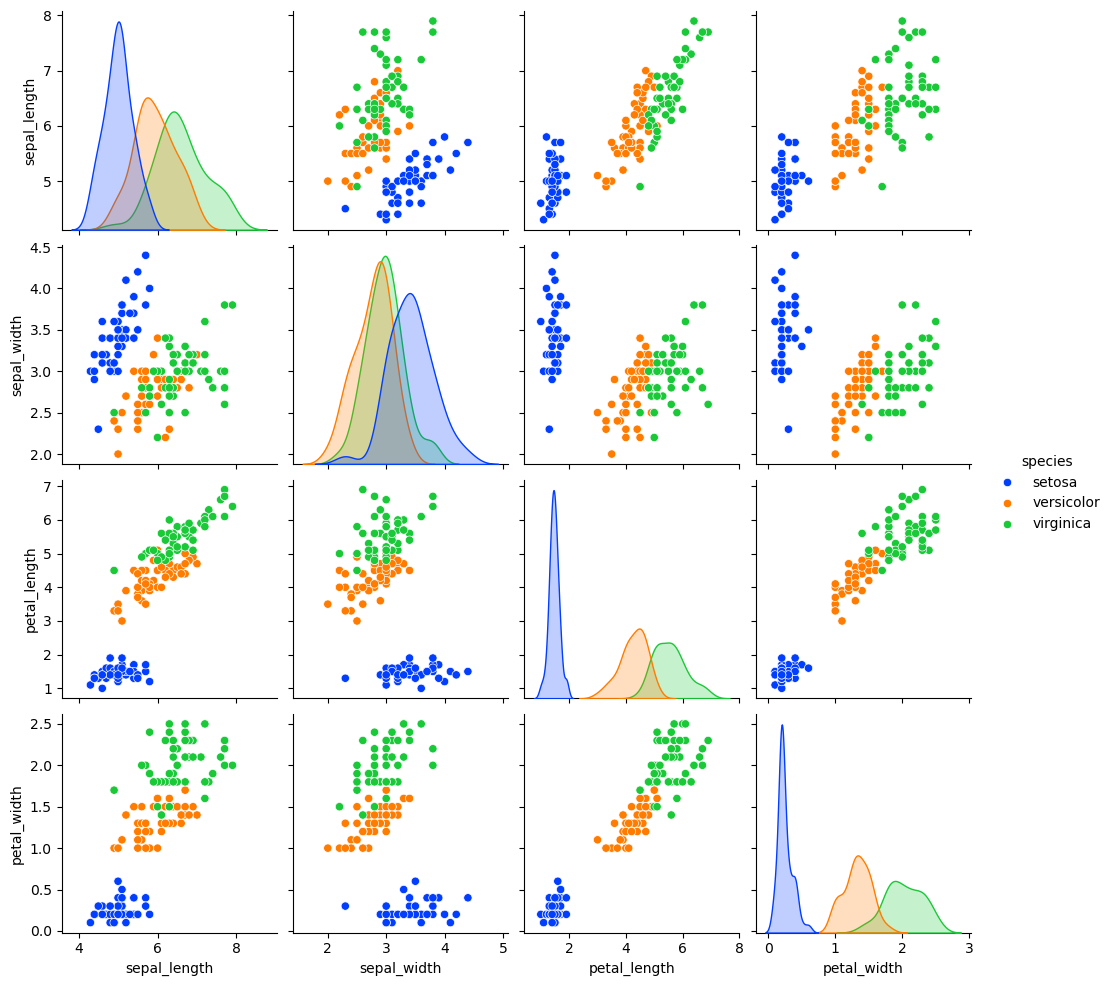

In [6]:
# Avec Seaborn, on peut construire le corrélogramme de ce dataset:
sns.pairplot(iris_df,hue='species',palette='bright')


<font color="RED" size="+1"><b>[Q]</b></font> Examiner ce corrélogramme et expliquer ce qu'il représente:
- pourquoi certains affichages représentent des points et d'autres des courbes ?

De plus, en examinant ce corrélogramme : 
- est-ce que le problème de classification des iris semble être un problème difficile ? Expliquez ?
- à votre avis, sans faire de calculs, quels sont les 2 attributs qui semblent le plus discrimant pour reconnaître la valeur de la classe ?

<i>Rajouter ci-dessous une boîte "markdown" pour donner vos réponses.</i>

Affichages des points : chaque point représente une fleur 

Affichages des courbes : variable qui prend des valeurs pour chaque espèce d'iris

Ce n'est pas un problème difficile car les nuages de points de chaque espèce sont assez bien séparés

petal_length et petal_width séparent le mieux les 3 espèces.

### Préparation

In [7]:
# Passer du dataframe à des arrays:
iris_desc = np.array(iris_df[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']])
iris_label = np.array(iris_df['species']) # species est la colonne contenant le label/la classe.

# obtenir les noms des colonnes :
iris_noms = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

print("Noms des features: ",iris_noms)
print("Noms des labels: ",np.unique(iris_label))

Noms des features:  ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
Noms des labels:  ['setosa' 'versicolor' 'virginica']


In [8]:
# Exemple : fleurs dont la 'sepal_length' vaut 6.3
iris_label[iris_desc[:,0] == 6.3]

array(['versicolor', 'versicolor', 'versicolor', 'virginica', 'virginica',
       'virginica', 'virginica', 'virginica', 'virginica'], dtype=object)

<font color="RED" size="+1"><b>[Q]</b></font> Vérifier que la fonction <code>classe_majoritaire</code> et la fonction d'<code>entropie</code> écrites lors du TME précédent sont bien installées dans votre librairie.



In [9]:
# Vérification sur nos données:
liste_classes = iris_label[iris_desc[:,0] == 6.3]
classe_majo = classif.classe_majoritaire(liste_classes)

print("Les classes: ", liste_classes)
print("Classe majoritaire: ", classe_majo)
print(f'Entropie: {classif.entropie(liste_classes):0.3f}')

Les classes:  ['versicolor' 'versicolor' 'versicolor' 'virginica' 'virginica'
 'virginica' 'virginica' 'virginica' 'virginica']
Classe majoritaire:  versicolor
Entropie: 0.918


### Discrétisation des attributs numériques

<div class="alert alert-block alert-success">
    
Comme cela a été dit en cours, **discrétiser** un attribut numérique consiste en trouver un seuil de coupure dans son ensemble de valeurs après les avoir ordonnées.
</div>    


Ci-dessous, la méthode <code>discretise</code> qui permet de trouver le seuil de coupure optimal dans un ensemble de valeurs associées à des classes (labels).


In [10]:
def discretise(m_desc, m_class, num_col):
    """ input:
            - m_desc : (np.array) matrice des descriptions toutes numériques
            - m_class : (np.array) matrice des classes (correspondant à m_desc)
            - num_col : (int) numéro de colonne de m_desc à considérer
            - nb_classes : (int) nombre initial de labels dans le dataset (défaut: 2)
        output: tuple : ((seuil_trouve, entropie), (liste_coupures,liste_entropies))
            -> seuil_trouve (float): meilleur seuil trouvé
            -> entropie (float): entropie du seuil trouvé (celle qui minimise)
            -> liste_coupures (List[float]): la liste des valeurs seuils qui ont été regardées
            -> liste_entropies (List[float]): la liste des entropies correspondantes aux seuils regardés
            (les 2 listes correspondent et sont donc de même taille)
            REMARQUE: dans le cas où il y a moins de 2 valeurs d'attribut dans m_desc, aucune discrétisation
            n'est possible, on rend donc ((None , +Inf), ([],[])) dans ce cas            
    """
    # Liste triée des valeurs différentes présentes dans m_desc:
    l_valeurs = np.unique(m_desc[:,num_col])
    
    # Si on a moins de 2 valeurs, pas la peine de discrétiser:
    if (len(l_valeurs) < 2):
        return ((None, float('Inf')), ([],[]))
    
    # Initialisation
    best_seuil = None
    best_entropie = float('Inf')
    
    # pour voir ce qui se passe, on va sauver les entropies trouvées et les points de coupures:
    liste_entropies = []
    liste_coupures = []
    
    nb_exemples = len(m_class)
    
    for v in l_valeurs:
        cl_inf = m_class[m_desc[:,num_col]<=v]
        cl_sup = m_class[m_desc[:,num_col]>v]
        nb_inf = len(cl_inf)
        nb_sup = len(cl_sup)
        
        # calcul de l'entropie de la coupure
        val_entropie_inf = classif.entropie(cl_inf) # entropie de l'ensemble des inf
        val_entropie_sup = classif.entropie(cl_sup) # entropie de l'ensemble des sup
        
        val_entropie = (nb_inf / float(nb_exemples)) * val_entropie_inf \
                       + (nb_sup / float(nb_exemples)) * val_entropie_sup
        
        # Ajout de la valeur trouvée pour retourner l'ensemble des entropies trouvées:
        liste_coupures.append(v)
        liste_entropies.append(val_entropie)
        
        # si cette coupure minimise l'entropie, on mémorise ce seuil et son entropie:
        if (best_entropie > val_entropie):
            best_entropie = val_entropie
            best_seuil = v
    
    return (best_seuil, best_entropie), (liste_coupures,liste_entropies)

Pour  sepal_length
Seuil de coupure trouvé: 5.500 et son entropie: 0.64843


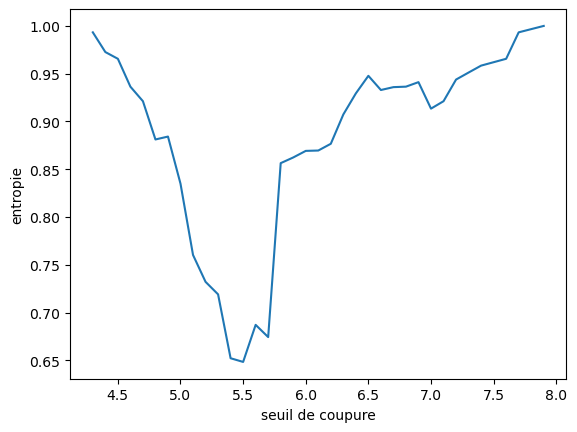

In [11]:
# Exemple d'utilisation:
numero_colonne = 0
resultat, liste_vals = discretise(iris_desc,iris_label,numero_colonne)

print("Pour ", iris_noms[numero_colonne])
print(f"Seuil de coupure trouvé: {resultat[0]:1.3f} et son entropie: {resultat[1]:1.5f}" )

# affichage de la variation de l'entropie en fonction du choix du seuil:
X,Y = liste_vals
plt.plot(X,Y)
plt.ylabel('entropie')
plt.xlabel('seuil de coupure')
plt.show()

Pour  petal_length
Seuil de coupure trouvé: 1.700 et son entropie: 0.48036


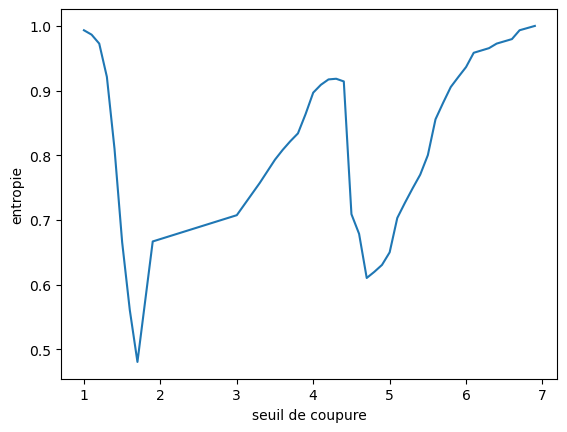

In [12]:
# Autre exemple:
numero_colonne = 2

resultat, liste_vals = discretise(iris_desc,iris_label,numero_colonne)

print("Pour ", iris_noms[numero_colonne])
print(f"Seuil de coupure trouvé: {resultat[0]:1.3f} et son entropie: {resultat[1]:1.5f}" )

# affichage de la variation de l'entropie en fonction du choix du seuil:
X,Y = liste_vals
plt.plot(X,Y)
plt.ylabel('entropie')
plt.xlabel('seuil de coupure')
plt.show()

<div class="alert alert-block alert-warning">
Une fois un seuil de coupure $s$ trouvé sur un attribut $n$, on partitionne la base d'apprentissage en 2 ensembles:
- l'ensemble des exemples qui ont une valeur inférieure ou égale à $s$ pour l'attribut $n$
- l'ensemble des exemples qui ont une valeur strictement supérieure à $s$ pour l'attribut $n$
</div>    


La fonction <code>partionne</code> ci-dessous prend en argument deux numpy array $m_{desc}$ et $m_{class}$ qui représentent une base d'apprentissage, un numéro de colonne $n$ et une valeur de seuil $s$ et rend un tuple composé  de 2 tuples de numpy arrays:
- le premier tuple est composé de l'ensemble des descriptions de tous les exemples de $T$ qui ont une valeur pour la colonne $n$ inférieure ou égale à $s$ et l'ensemble de leur classe;
- le second tuple est composé de l'ensemble des descriptions de tous les exemples de $T$ qui ont une valeur pour la colonne $n$ strictement supérieure à $s$ et l'ensemble de leur classe;


In [13]:
def partitionne(m_desc,m_class,n,s):
    """ input:
            - m_desc : (np.array) matrice des descriptions toutes numériques
            - m_class : (np.array) matrice des classes (correspondant à m_desc)
            - n : (int) numéro de colonne de m_desc
            - s : (float) seuil pour le critère d'arrêt
        Hypothèse: m_desc peut être partitionné ! (il contient au moins 2 valeurs différentes)
        output: un tuple composé de 2 tuples
    """
    return ((m_desc[m_desc[:,n]<=s], m_class[m_desc[:,n]<=s]), \
            (m_desc[m_desc[:,n]>s], m_class[m_desc[:,n]>s]))

In [14]:
# Exemple d'utilisation :

# Recherche point de coupure :
numero_colonne = 3
resultat, liste_vals = discretise(iris_desc,iris_label,numero_colonne)
print(f"Seuil de coupure trouvé: {resultat[0]:1.3f} et son entropie: {resultat[1]:1.5f}" )

# partitionnement :
((left_data,left_class), (right_data,right_class)) = partitionne(iris_desc,iris_label, numero_colonne,resultat[0])

print("Nombre d'exemples à gauche : ", len(left_class), " Nombre d'exemples à droite : ", len(right_class) )

Seuil de coupure trouvé: 0.500 et son entropie: 0.45466
Nombre d'exemples à gauche :  49  Nombre d'exemples à droite :  101


### Implémentation des arbres numériques

Afin de représenter des arbres de décision numériques, on créé une nouvelle classe qui permet de définir des noeuds internes de l'arbre associés à des attributs numériques.

<b>Remarque:</b> on se place ici dans le cas où l'arbre de décision final ne contiendra que des noeuds numériques. Il n'y a donc pas à prévoir de noeud catégoriel dans cet arbre (la version générale sera abordée un peu plus loin dans ce notebook).

<font color="RED" size="+1"><b>[Q]</b></font> Compléter la classe suivante pour pouvoir classifier avec un noeud numérique.

In [15]:
import graphviz as gv   # si ce n'a pas déjà été fait...

class NoeudNumerique:
    """ Classe pour représenter des noeuds numériques d'un arbre de décision
    """
    def __init__(self, num_att=-1, nom=''):
        """ Constructeur: il prend en argument
            - num_att (int) : le numéro de l'attribut auquel il se rapporte: de 0 à ...
              si le noeud se rapporte à la classe, le numéro est -1, on n'a pas besoin
              de le préciser
            - nom (str) : une chaîne de caractères donnant le nom de l'attribut si
              il est connu (sinon, on ne met rien et le nom sera donné de façon 
              générique: "att_Numéro")
        """
        self.attribut = num_att    # numéro de l'attribut
        if (nom == ''):            # son nom si connu
            self.nom_attribut = 'att_'+str(num_att)
        else:
            self.nom_attribut = nom 
        self.seuil = None          # seuil de coupure pour ce noeud
        self.Les_fils = None       # aucun fils à la création, ils seront ajoutés
        self.classe   = None       # valeur de la classe si c'est une feuille
        
    def est_feuille(self):
        """ rend True si l'arbre est une feuille 
            c'est une feuille s'il n'a aucun fils
        """
        return self.Les_fils == None
    
    def ajoute_fils(self, val_seuil, fils_inf, fils_sup):
        """ val_seuil : valeur du seuil de coupure
            fils_inf : fils à atteindre pour les valeurs inférieures ou égales à seuil
            fils_sup : fils à atteindre pour les valeurs supérieures à seuil
        """
        if self.Les_fils == None:
            self.Les_fils = dict()            
        self.seuil = val_seuil
        self.Les_fils['inf'] = fils_inf
        self.Les_fils['sup'] = fils_sup        
    
    def ajoute_feuille(self,classe):
        """ classe: valeur de la classe
            Ce noeud devient un noeud feuille
        """
        self.classe    = classe
        self.Les_fils  = None   # normalement, pas obligatoire ici, c'est pour être sûr
        
    def classifie(self, exemple):
        """ exemple : numpy.array
            rend la classe de l'exemple (pour nous, soit +1, soit -1 en général)
            on rend la valeur 0 si l'exemple ne peut pas être classé (cf. les questions
            posées en fin de ce notebook)
        """
        #############
        # COMPLETER CETTE PARTIE   
        if self.est_feuille():
            return self.classe
    
        if exemple[self.attribut] <= self.seuil:
            return self.Les_fils['inf'].classifie(exemple)
        else:
            return self.Les_fils['sup'].classifie(exemple)
        #############

    
    def compte_feuilles(self):
        """ rend le nombre de feuilles sous ce noeud
        """
        #############
        # COMPLETER CETTE PARTIE AUSSI
        if self.est_feuille():
            return 1
        
        nbg = self.Les_fils['inf'].compte_feuilles() #sous arbre gauche
        nbd = self.Les_fils['sup'].compte_feuilles() #sous arbre droit
        return nbg + nbd
        #############
     
    def to_graph(self, g, prefixe='A'):
        """ construit une représentation de l'arbre pour pouvoir l'afficher graphiquement
            Cette fonction ne nous intéressera pas plus que ça, elle ne sera donc 
            pas expliquée            
        """
        if self.est_feuille():
            g.node(prefixe,str(self.classe),shape='box')
        else:
            g.node(prefixe, str(self.nom_attribut))
            self.Les_fils['inf'].to_graph(g,prefixe+"g")
            self.Les_fils['sup'].to_graph(g,prefixe+"d")
            g.edge(prefixe,prefixe+"g", '<='+ str(self.seuil))
            g.edge(prefixe,prefixe+"d", '>'+ str(self.seuil))                
        return g


Cet arbre contient  2  feuilles.


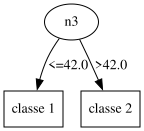

In [16]:
# Exemple d'utilisation: 
un_arbre= NoeudNumerique(nom='n1')
un_arbre.ajoute_feuille("classe 1")
un_arbre.est_feuille()
un_arbre1 = NoeudNumerique(nom="n2")
un_arbre1.ajoute_feuille("classe 2")
un_arbre2 = NoeudNumerique(nom="n3")
un_arbre2.ajoute_fils(42.0,un_arbre,un_arbre1)
print("Cet arbre contient ", un_arbre2.compte_feuilles()," feuilles.")

gtree = gv.Digraph(format='png')
un_arbre2.to_graph(gtree)



<font color="RED" size="+1"><b>[Q]</b></font> En utilisant la fonction `discretise`, compléter la fonction `construit_AD_num` (ça ressemble à la version catégorielle réalisée lors de la séance précédente) afin de pouvoir construire des arbres de décision avec des valeurs numériques.
Les attributs numériques seront discrétisés en 2 valeurs catégorielles.

In [17]:
def construit_AD_num(X,Y,epsilon,LNoms = []):
    """ X,Y : dataset
        epsilon : seuil d'entropie pour le critère d'arrêt 
        LNoms : liste des noms de features (colonnes) de description 
    """
    
    # dimensions de X:
    (nb_lig, nb_col) = X.shape
    
    entropie_classe = classif.entropie(Y)
    
    if (entropie_classe <= epsilon) or  (nb_lig <=1):
        # ARRET : on crée une feuille
        noeud = NoeudNumerique(-1,"Label")
        noeud.ajoute_feuille(classif.classe_majoritaire(Y))
    else:
        gain_max = 0.0  # meilleur gain trouvé (initalisé à 0.0 => aucun gain)
        i_best = -1     # numéro du meilleur attribut (init à -1 (aucun))
        
        #############
        
        # COMPLETER CETTE PARTIE : ELLE DOIT PERMETTRE D'OBTENIR DANS
        # i_best : le numéro de l'attribut qui maximise le gain d'information.  En cas d'égalité,
        #          le premier rencontré est choisi.
        # gain_max : la plus grande valeur de gain d'information trouvée.
        # Xbest_tuple : le tuple rendu par partionne() pour le meilleur attribut trouvé
        # Xbest_seuil : le seuil de partitionnement associé au meilleur attribut
        #
        # Remarque : attention, la fonction discretise() peut renvoyer un tuple contenant
        # None (pas de partitionnement possible)n dans ce cas, on considèrera que le
        # résultat d'un partitionnement est alors ((X,Y),(None,None))
        
        Xbest_tuple = None  
        Xbest_seuil = None  # seuil de coupure 
        
        for i in range(nb_col):
            (seuil_tuple, _) = discretise(X, Y, i)
            best_seuil, best_entropy = seuil_tuple
            #aucun seuil trouvé
            if best_seuil is None:
                continue
            gain = entropie_classe - best_entropy
            if gain > gain_max:
                gain_max = gain
                i_best = i
                Xbest_seuil = best_seuil
                Xbest_tuple = partitionne(X, Y, i, best_seuil)
        

        ############
        if (i_best != -1): # Un attribut qui amène un gain d'information >0 a été trouvé
            if len(LNoms)>0:  # si on a des noms de features
                noeud = NoeudNumerique(i_best,LNoms[i_best]) 
            else:
                noeud = NoeudNumerique(i_best)
            ((left_data,left_class), (right_data,right_class)) = Xbest_tuple
            noeud.ajoute_fils( Xbest_seuil, \
                              construit_AD_num(left_data,left_class, epsilon, LNoms), \
                              construit_AD_num(right_data,right_class, epsilon, LNoms) )
        else: # aucun attribut n'a pu améliorer le gain d'information
              # ARRET : on crée une feuille
            noeud = NoeudNumerique(-1,"Label")
            noeud.ajoute_feuille(classif.classe_majoritaire(Y))
        
    return noeud

In [18]:
class ClassifierArbreNumerique(classif.Classifier):
    """ Classe pour représenter un classifieur par arbre de décision numérique
    """
    
    def __init__(self, input_dimension, epsilon, LNoms=[]):
        """ Constructeur
            Argument:
                - intput_dimension (int) : dimension de la description des exemples
                - epsilon (float) : paramètre de l'algorithme (cf. explications précédentes)
                - LNoms : Liste des noms de dimensions (si connues)
            Hypothèse : input_dimension > 0
        """
        self.dimension = input_dimension
        self.epsilon = epsilon
        self.LNoms = LNoms
        # l'arbre est manipulé par sa racine qui sera un Noeud
        self.racine = None
        
    def toString(self):
        """  -> str
            rend le nom du classifieur avec ses paramètres
        """
        return 'ClassifierArbreDecision ['+str(self.dimension) + '] eps='+str(self.epsilon)
        
    def train(self, desc_set, label_set):
        """ Permet d'entrainer le modele sur l'ensemble donné
            desc_set: ndarray avec des descriptions
            label_set: ndarray avec les labels correspondants
            Hypothèse: desc_set et label_set ont le même nombre de lignes
        """        
        self.racine = construit_AD_num(desc_set,label_set,self.epsilon,self.LNoms)
    
    def score(self,x):
        """ rend le score de prédiction sur x (valeur réelle)
            x: une description
        """
        # cette méthode ne fait rien dans notre implémentation :
        pass
    
    def predict(self, x):
        """ x (array): une description d'exemple
            rend la prediction sur x             
        """
        return self.racine.classifie(x)

    def accuracy(self, desc_set, label_set):  # Version propre à aux arbres
        """ Permet de calculer la qualité du système sur un dataset donné
            desc_set: ndarray avec des descriptions
            label_set: ndarray avec les labels correspondants
            Hypothèse: desc_set et label_set ont le même nombre de lignes
        """
        nb_ok=0
        for i in range(desc_set.shape[0]):
            if self.predict(desc_set[i,:]) == label_set[i]:
                nb_ok=nb_ok+1
        acc=nb_ok/(desc_set.shape[0] * 1.0)
        return acc

    def number_leaves(self):
        """ rend le nombre de feuilles de l'arbre
        """
        return self.racine.compte_feuilles()
    
    def affiche(self,GTree):
        """ affichage de l'arbre sous forme graphique
            Cette fonction modifie GTree par effet de bord
        """
        self.racine.to_graph(GTree)
# ---------------------------


Cet arbre possède  11  feuilles.


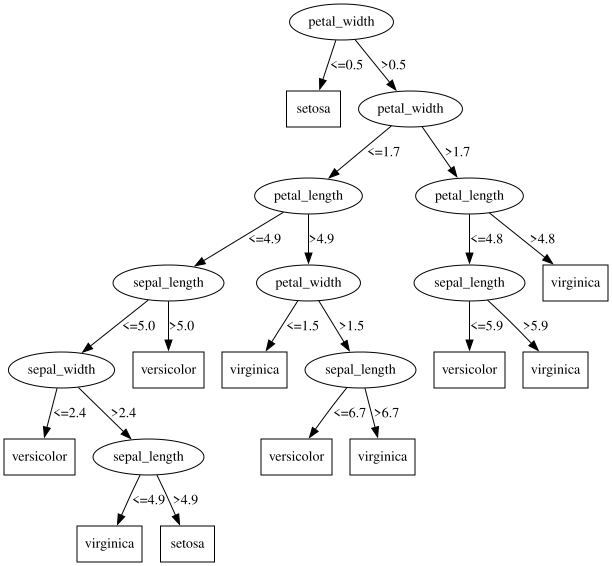

In [19]:
# Initialiation d'un arbre pour le dataset Iris:
arbre_iris = ClassifierArbreNumerique(len(iris_noms), 0.0, iris_noms)

# Construction de l'arbre de décision à partir du dataset Iris
arbre_iris.train(iris_desc,iris_label)

# Construction de la représentation graphique (affichage)
graphe_arbre_iris = gv.Digraph(format='png')
arbre_iris.affiche(graphe_arbre_iris)

# Affichage du graphe obtenu:
print("Cet arbre possède ",arbre_iris.number_leaves()," feuilles.")
graphe_arbre_iris    # ---> Cet arbre possède 11 feuilles...

In [20]:
# mesure du taux de bonne classification
arbre_iris.accuracy(iris_desc,iris_label)

1.0

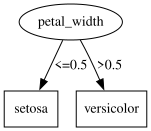

In [21]:
# Nouvel essai avec un seuil d'entropie élevé:
# Initialiation d'un arbre pour le dataset Elections:
arbre_iris2 = ClassifierArbreNumerique(len(iris_noms),0.75, iris_noms)

# Construction de l'arbre de décision à partir du dataset Elections
arbre_iris2.train(iris_desc,iris_label)

# Construction de la représentation graphique (affichage)
graphe_arbre_iris2 = gv.Digraph(format='png')
arbre_iris2.affiche(graphe_arbre_iris2)

# Affichage du graphe obtenu:
graphe_arbre_iris2

In [22]:
# mesure du taux de bonne classification
arbre_iris2.accuracy(iris_desc,iris_label)

0.66

### Expérimentations

<font color="RED" size="+1"><b>[Q]</b></font> Tester cet algorithme en effectuant une validation croisée sur les données des iris (en prenant $0.0$ comme seuil d'entropie).

In [23]:
print("Remarque: j'ai mis des affichage dans la fonction validation croisée afin de montrer ce qui se passe.\n")


tic = time.time()
# ################### A COMPLETER 

classif_instance = ClassifierArbreNumerique(len(iris_noms),0,iris_noms)

res_all, res_moy, res_sd = ev.validation_croisee(classif_instance,(iris_desc, iris_label),10)

# ################### 
toc = time.time()
       
print("\nValidation croisée sur les iris avec comme seuil ",0.0)
print("Perf obtenues : ",res_all)
print(f'\nAccuracy moyenne: {res_moy:.3f}\técart type: {res_sd:.3f}')
print(f'Temps mis: {(toc-tic):.3f}s')

Remarque: j'ai mis des affichage dans la fonction validation croisée afin de montrer ce qui se passe.


Validation croisée sur les iris avec comme seuil  0.0
Perf obtenues :  [0.9, 0.9666666666666667, 0.9666666666666667, 0.9, 0.9, 0.9333333333333333, 0.9666666666666667, 0.8, 0.8666666666666667, 0.9333333333333333]

Accuracy moyenne: 0.913	écart type: 0.050
Temps mis: 0.424s


<font color="RED" size="+1"><b>[Q]</b></font> Etudier la variation du taux de bonne classification lorsque l'on fait varier le seuil d'entropie utilisé pour l'apprentissage. Tracer ensuite la courbe de l'accuracy moyenne (incluant son écart type) quand le seuil d'entropie varie.

run  0: seuil d'entropie = 0.000	 accuracy moyenne: 0.930	 écart type: 0.050	 (temps: 0.400s)
run  1: seuil d'entropie = 0.101	 accuracy moyenne: 0.933	 écart type: 0.039	 (temps: 0.382s)
run  2: seuil d'entropie = 0.202	 accuracy moyenne: 0.883	 écart type: 0.110	 (temps: 0.349s)
run  3: seuil d'entropie = 0.303	 accuracy moyenne: 0.957	 écart type: 0.033	 (temps: 0.294s)
run  4: seuil d'entropie = 0.404	 accuracy moyenne: 0.907	 écart type: 0.071	 (temps: 0.221s)
run  5: seuil d'entropie = 0.505	 accuracy moyenne: 0.867	 écart type: 0.121	 (temps: 0.213s)
run  6: seuil d'entropie = 0.606	 accuracy moyenne: 0.867	 écart type: 0.068	 (temps: 0.220s)
run  7: seuil d'entropie = 0.707	 accuracy moyenne: 0.673	 écart type: 0.129	 (temps: 0.136s)
run  8: seuil d'entropie = 0.808	 accuracy moyenne: 0.623	 écart type: 0.076	 (temps: 0.128s)
run  9: seuil d'entropie = 0.909	 accuracy moyenne: 0.650	 écart type: 0.076	 (temps: 0.136s)
run 10: seuil d'entropie = 1.010	 accuracy moyenne: 0.317	 é

Text(0, 0.5, 'Accuracy moyenne')

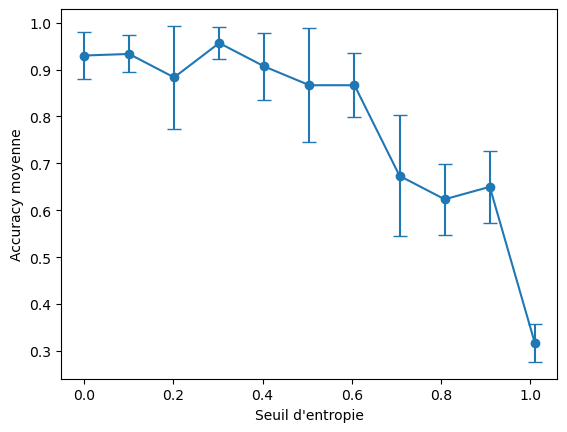

In [24]:
# ################### A COMPLETER 

epsilon_values = np.linspace(0,1.01,11)

accuracies_mean = []
accuracies_std = []
times_run = []

for i in range(len(epsilon_values)):
    tic = time.time()
    
    classifier = ClassifierArbreNumerique(len(iris_noms), epsilon_values[i], iris_noms)
    
    res_all, res_moy, res_sd = ev.validation_croisee(classifier, (iris_desc, iris_label), 10)
    
    toc = time.time()
    duree = toc-tic
    
    accuracies_mean.append(res_moy)
    accuracies_std.append(res_sd)
    times_run.append(duree)
    
    print(f"run {i:2d}: seuil d'entropie = {epsilon_values[i]:1.3f}\t accuracy moyenne: {res_moy:1.3f}\t écart type: {res_sd:1.3f}\t (temps: {duree:1.3f}s)")
    
# Tracé de la courbe avec les barres d'erreur (accuracy moyenne ± écart type)
plt.errorbar(epsilon_values, accuracies_mean, yerr=accuracies_std, fmt='-o', capsize=5)
plt.xlabel("Seuil d'entropie")
plt.ylabel("Accuracy moyenne")


# ################### 



Pour pouvoir afficher la courbe des variations de l'accuracy en affichant aussi l'écart type correspondant à chaque valeur, on utilise la fonction `lineplot` de seaborn, pour cela, il est nécessaire dans un premier temps de mettre les résultats obtenus dans un dataframe :
- avec 2 colonnes: 'Entropie' et 'Accuracy'
- chaque ligne donne le résultat d'un taux de bonne classification obtenu dans la validation croisée pour une valeur de seuil d'entropie : il y a donc 10 lignes par seuil d'entropie, chaque ligne avec le résultat d'une étape de la validation croisée.

<font color="RED" size="+1"><b>[Q]</b></font> Construire le dataframe ainsi défini.

In [25]:
df_res = pd.DataFrame(columns=['Entropie', 'Accuracy'])

# ################### A COMPLETER 
lignes = []
epsilon_values = np.linspace(0, 1.01, 11)

for eps in epsilon_values:
    for i in range(10):
        X_train, Y_train, X_test, Y_test = ev.crossval_strat(iris_desc, iris_label, 10, i)
        # On vérifie que le test set n'est pas vide (devrait être le cas normalement)
        if X_test.shape[0] == 0:
            continue
        classifier = ClassifierArbreNumerique(len(iris_noms), eps, iris_noms)
        classifier.train(X_train, Y_train)
        acc = classifier.accuracy(X_test, Y_test)
        lignes.append({'Entropie': eps, 'Accuracy': acc})

df_res = pd.DataFrame(lignes)
# ################### 
# Le datataframe obtenu :
df_res

,Entropie,Accuracy
0,0.00,0.933333
1,0.00,0.933333
2,0.00,1.000000
3,0.00,0.933333
4,0.00,1.000000
...,...,...
105,1.01,0.333333
106,1.01,0.333333
107,1.01,0.333333
108,1.01,0.333333


L'affichage se fait avec la fonction `lineplot` de seaborn. 

**Remarque**: le calcul de la moyenne et de l'écart type pour une même valeur de seuil est géré par la fonction.

<Axes: xlabel='Entropie', ylabel='Accuracy'>

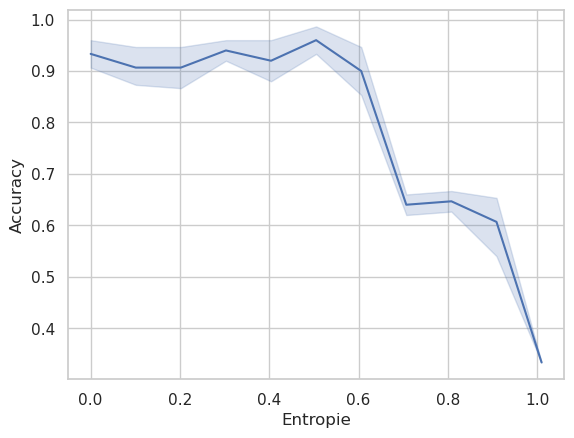

In [26]:
# Tracé avec lineplot de seaborn:
sns.set_theme(style="whitegrid")
sns.lineplot(x="Entropie", y="Accuracy", data=df_res)

<font color="RED" size="+1"><b>[Q]</b></font> Comparer les résultats obtenus avec la validation croisée avec les résultats obtenus avec les autres classifieurs (numériques) que vous avez implémentés.

<b>Remarque:</b> pour pouvoir utiliser les algorithmes précédents (knn, perceptron,...) vous devez utiliser leur version multi-classes.

In [27]:
nb_classes = len(np.unique(iris_label))

classifiers = {
    "KNN": classif.ClassifierMultiOAA(classif.ClassifierKNN(len(iris_noms), k=3), nb_classes),
    "Perceptron": classif.ClassifierMultiOAA(classif.ClassifierPerceptron(len(iris_noms)), nb_classes),
    "Perceptron Biais": classif.ClassifierMultiOAA(classif.ClassifierPerceptronBiais(len(iris_noms)), nb_classes),
    "Linéaire Aléatoire": classif.ClassifierMultiOAA(classif.ClassifierLineaireRandom(len(iris_noms)), nb_classes),
    "Arbre Numérique": classif.ClassifierArbreNumerique(len(iris_noms), epsilon=0.1, LNoms=iris_noms)
}

res = []

for name, clf in classifiers.items():
    perf, perf_moyenne, perf_ecart = ev.validation_croisee(clf, (iris_desc, iris_label), nb_iter=10)
    res.append({'Classifieur': name, 'Accuracy_Moyenne': perf_moyenne, 'Accuracy_Ecart-Type': perf_ecart})

df_comp = pd.DataFrame(res)
df_comp


Init perceptron biais: w=  [0. 0. 0. 0.]  learning rate=  0.01
Pas d'apprentissage pour ce classifieur
Pas d'apprentissage pour ce classifieur
Pas d'apprentissage pour ce classifieur
Pas d'apprentissage pour ce classifieur
Pas d'apprentissage pour ce classifieur
Pas d'apprentissage pour ce classifieur
Pas d'apprentissage pour ce classifieur
Pas d'apprentissage pour ce classifieur
Pas d'apprentissage pour ce classifieur
Pas d'apprentissage pour ce classifieur
Pas d'apprentissage pour ce classifieur
Pas d'apprentissage pour ce classifieur
Pas d'apprentissage pour ce classifieur
Pas d'apprentissage pour ce classifieur
Pas d'apprentissage pour ce classifieur
Pas d'apprentissage pour ce classifieur
Pas d'apprentissage pour ce classifieur
Pas d'apprentissage pour ce classifieur
Pas d'apprentissage pour ce classifieur
Pas d'apprentissage pour ce classifieur
Pas d'apprentissage pour ce classifieur
Pas d'apprentissage pour ce classifieur
Pas d'apprentissage pour ce classifieur
Pas d'apprentissa

,Classifieur,Accuracy_Moyenne,Accuracy_Ecart-Type
0,KNN,0.00,0.000000
1,Perceptron,0.00,0.000000
2,Perceptron Biais,0.00,0.000000
3,Linéaire Aléatoire,0.00,0.000000
4,Arbre Numérique,0.92,0.056174


### Pour aller plus loin... (optionnel)

La version générale d'un classifieur par arbre de décision doit pouvoir gérer des datasets contenant à la fois des variables numériques mais aussi catégorielles. En "fusionnant" les 2 classes `ClassifierArbreDecision` et `ClassifierArbreNumerique`, définissez une classe `ClassifierArbre` qui implémente cette version générale.

# Apprentissage non supervisé : la classification hiérarchique ascendante

Dans cette partie, le travail à réaliser décompose en 2 phases :
- dans la phase 1, le travail porte sur la base d'apprentissage <code>base-2D.csv</code> qui contient des exemples décrits dans $R^2$. Ainsi, il est plus aisé de visualiser les résultats des fonctions à écrire ;
- dans la phase 2, les fonctions écrites dans la phase précédente sont à utiliser avec la base d'apprentissage `base-Paris.csv`.

**Attention**: vos fonctions doivent **dès leur création** pouvoir s'appliquer **quelle que soit la dimension** des exemples traités.

**Remarque**: pour écrire les fonctions demandées, il est important d'éviter d'utiliser des boucles autant que possible.

### Phase 1: implémentation des fonctions et travail sur base_2D.csv

#### Chargement du fichier "base_2D.csv"

Charger le fichier `base_2D.csv` et, par exemple avec la fonction `read_csv` de pandas. Le résultat est stocké sous la forme d'un dataframe.

In [28]:
data_2D =  pd.read_csv("data/base-2D.csv") # A COMPLETER


print("Il y a", len(data_2D), "exemples dans la base.")

Il y a 14 exemples dans la base.


In [29]:
# Le dataframe correspondant:
data_2D

,X1,X2
0,0.0,4.0
1,1.0,3.5
2,1.0,1.0
3,2.0,1.0
4,2.0,2.0
5,4.0,4.0
6,4.0,5.0
7,4.0,6.0
8,4.5,1.0
9,4.5,6.0


<font size="+1" color="RED">**[Q]**</font> Afficher la base sous forme graphique.


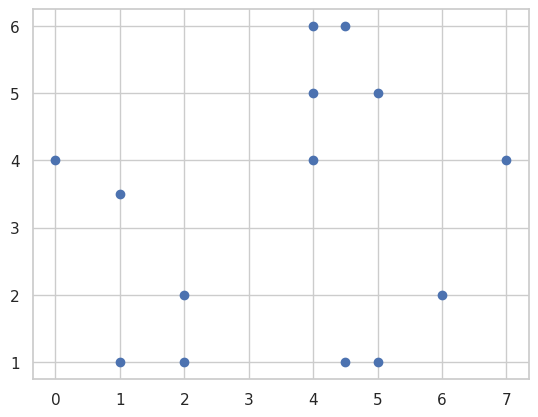

In [30]:
x1 = data_2D.iloc[:,0]
x2 = data_2D.iloc[:,1]

if data_2D.shape[1] > 2:
    labels = data_2D.iloc[:,-1]
    plt.scatter(x1, x2, c=labels)
else:
    plt.scatter(x1, x2)

plt.grid(True)
plt.show()


#### Normalisation des données

<font size="+1" color="RED"><b>[Q]</b></font> Donner les instructions permettant d'afficher les valeurs minimales et maximales de chaque colonne du dataframe `base_2D`.

Remarque : soyez général ! Il faut que ces instructions restent valables quel que soit le dataframe donné (noms et nombre de colonnes non connus au départ par exemple).


In [31]:
print("Minimum et maximum de chaque colonne:")
for col in data_2D.columns:
    min_val = data_2D[col].min()
    max_val = data_2D[col].max()
    print(f"colonne {col} : {min_val} {max_val}")


Minimum et maximum de chaque colonne:
colonne X1 : 0.0 7.0
colonne X2 : 1.0 6.0


<font size="+1" color="RED"><b>[Q]</b></font> En utilisant le minimum et le maximum de chaque variable, et en se référant à la méthode de normalisation présentée au cours 8, écrire la fonction <code>normalisation</code> qui prend en argument un <code>DataFrame</code> et rend le dataframe obtenu en normalisant chaque colonne de ce <code>DataFrame</code> (ie. les valeurs de la matrice résultat doivent être dans l'intervalle $[0,1])$.


In [32]:
def normalisation(df):
    df_norm = (df-df.min()) / (df.max()-df.min())
    return df_norm


<font size="+1" color="RED"><b>[Q]</b></font> Normaliser les données de la base-2D et afficher leur représentation graphique: vérifier que le tracé est le même que celui obtenu avant la normalisation (aux valeurs des axes près).

In [33]:
data_2D_norm =  normalisation(data_2D) # A COMPLETER

X1_values = data_2D_norm.iloc[:, 0]
X2_values = data_2D_norm.iloc[:, 1]




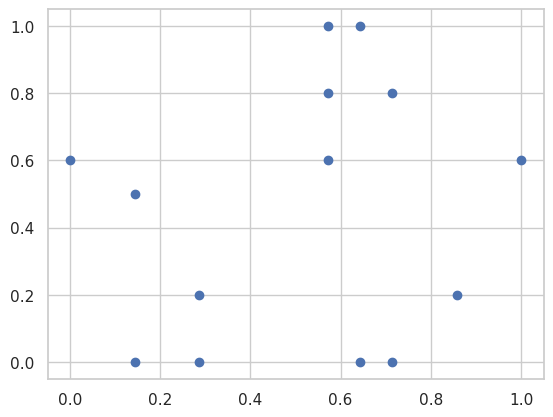

In [34]:
# le résultat du plot est identique au précédent, aux valeurs des axes près.
plt.scatter(X1_values,X2_values)


#### Distances entre exemples

<font size="+1" color="RED"><b>[Q]</b></font> Ecrire la fonction <code>dist_euclidienne</code> qui prend en argument deux exemples sous la forme de vecteurs (Dataframe ou np.array) et rend leur distance euclidienne. 

In [35]:
def dist_euclidienne(x1, x2):
    
    x1 = np.array(x1).flatten()
    x2 = np.array(x2).flatten()

    return np.linalg.norm(x1 - x2)


In [36]:
v1= data_2D_norm.iloc[0]
v2= data_2D_norm.iloc[1]
print("v1 : ",v1, "\nv2 : ",v2)
print("distance euclidienne entre v1 et v2 : ", dist_euclidienne(v1,v2))

v1 :  X1    0.0
X2    0.6
Name: 0, dtype: float64 
v2 :  X1    0.142857
X2    0.500000
Name: 1, dtype: float64
distance euclidienne entre v1 et v2 :  0.17437936593905287


In [37]:
# Remarque : si elle est bien écrite, la fonction doit fonctionner aussi pour un np.array:

v1= np.array(data_2D_norm.iloc[0])
v2= np.array(data_2D_norm.iloc[1])
print("v1 : ",v1, "\nv2 : ",v2)
print("distance euclidienne entre v1 et v2 : ", dist_euclidienne(v1,v2))

v1 :  [0.  0.6] 
v2 :  [0.14285714 0.5       ]
distance euclidienne entre v1 et v2 :  0.17437936593905287


In [38]:
# autre exemples:
v3= np.array([0,0,0])
v4= np.array([1,1,1])
print("v3 : ",v3, "\nv4 : ",v4)
print("distance euclidienne entre v3 et v4 : ", dist_euclidienne(v3,v4))
v5= np.array([0,0,0])
v6= np.array([-1,0,1])
print("v5 : ",v5, "\nv6 : ",v6)
print("distance euclidienne entre v5 et v6 : ", dist_euclidienne(v5,v6))

v3 :  [0 0 0] 
v4 :  [1 1 1]
distance euclidienne entre v3 et v4 :  1.7320508075688772
v5 :  [0 0 0] 
v6 :  [-1  0  1]
distance euclidienne entre v5 et v6 :  1.4142135623730951


#### Calcul de centroides

<font size="+1" color="RED"><b>[Q]</b></font> Ecrire la fonction <code>centroide</code> qui, étant donné un dataframe (ou un np.array) contenant plusieurs exemples rend leur centre de gravité (centroide).
On fait l'hypothèse qu'il y a toujours au moins un exemple.


In [39]:
def centroide(df):

    data = np.array(df)
    return np.mean(df,axis=0)


In [40]:
centroide(data_2D_norm)

X1    0.510204
X2    0.450000
dtype: float64

In [41]:
# Remarque : si elle est bien écrite, la fonction doit fonctionner aussi pour un np.array:
centroide( np.array(data_2D_norm) )

array([0.51020408, 0.45      ])

#### Distances entre groupes d'exemples (approche centroides)


La distance entre deux groupes d'exemples correspond à la distance entre leurs centroïdes (approche "centroid linkage"). Pour cette approche, on prendra seulement la distance euclidienne.

<font size="+1" color="RED"><b>[Q]</b></font> Ecrire la fonction <code>dist_centroides</code> qui prend en argument deux groupes de vecteurs (dataframe ou np.array) et qui rend leur distance euclidienne.


In [42]:
def dist_centroides(groupe1, groupe2):
    return np.linalg.norm(centroide(groupe1) - centroide(groupe2))

In [43]:
# Par exemple:
dist_centroides(data_2D_norm.iloc[0:4],data_2D_norm.iloc[5:13])

0.586345478713841

####  l'algorithme de classification hiérarchique

Dans la suite de cet exercice, une partition (qui est un groupe de clusters) est représentée par une structure de données de type dictionnaire (c'est à dire <code>dict()</code>) :
- la clé est un numéro de cluster (sous la forme d'un entier naturel) ;
- la valeur associée est un liste contenant les indices des exemples qui sont dans le cluster correspondant.

Les indices sont ceux du dataframe qui contient la base initiale.

<b>Dans ce qui suit, on appelle "partition" un tel dictionnaire.</b>


Rappel: `iloc` accepte une liste d'indices pour extraire des lignes d'un dataframe...

In [44]:
data_2D_norm.iloc[[0,3,1]]

,X1,X2
0,0.000000,0.6
3,0.285714,0.0
1,0.142857,0.5


<font size="+1" color="RED"><b>[Q]</b></font> Ecrire la fonction <code>initialise_CHA</code> qui, étant donné un dataframe DF représentant une base d'apprentissage, rend une partition contenant autant d'entrées que d'exemples dans DF. La clé de chaque entrée sera le numéro de l'exemple. Cette fonction sera spécifique au clustering hiérarchique ascendant (CHA).

In [45]:
def initialise_CHA(DF):
    partition = {}
    for i in range(len(DF)):
        partition[i] = [i]
    return partition

In [46]:
# Par exemple:
depart = initialise_CHA(data_2D_norm)
depart

{0: [0],
 1: [1],
 2: [2],
 3: [3],
 4: [4],
 5: [5],
 6: [6],
 7: [7],
 8: [8],
 9: [9],
 10: [10],
 11: [11],
 12: [12],
 13: [13]}

#### Variante 1: chaînage par centroides

On souhaite implémenter ici l'algorithme de classification hiérarchique basé sur l'approche "centroid linkage".

On commence par implémenter une fonction qui, étant donné une partition, permet de regrouper les 2 clusters les plus proches. Ces 2 clusters sont alors fusionnés pour n'en former qu'un seul qui est ajouté à la partition, alors que les 2 clusters initiaux sont retirés de la partition.

On fait l'hypothèse que la partition initiale contient au moins 2 groupes.

<font size="+1" color="RED"><b>[Q]</b></font> Ecrire la fonction <code>fusionne</code> qui prend en argument un dataframe contenant des exemples et une partition P0 et qui rend le tuple composé des 4 valeurs suivantes:
- la partition P1 obtenue après fusion des 2 clusters de P0 les plus proches ;
- les clés des 2 clusters de P0 qui ont été fusionnés et qui ne sont donc plus dans P1 ;
- la distance qui séparait ces 2 clusters, calculée selon le nom de distance donné.

Vous rajouterez un troisième argument (avec valeur par défaut) à la fonction : `verbose=False` qui indique si des messages doivent être affichés pour expliquer ce que fait la fonctionne. Les messages doivent tous commencer par "fusionne:".

In [65]:
def fusionne(DF, P0, verbose=False):
    best_distance = float('inf')
    best_pair = (None, None)
    keys = list(P0.keys())

    for i in range(len(keys) - 1):
        for j in range(i + 1, len(keys)):
            key1 = keys[i]
            key2 = keys[j]
            cluster1 = DF.iloc[P0[key1]]
            cluster2 = DF.iloc[P0[key2]]
            d = dist_centroides(cluster1, cluster2)
            if d < best_distance:
                best_distance = d
                best_pair = (key1, key2)

    cl1, cl2 = best_pair
    new_key = max(P0.keys()) + 1
    new_cluster = P0[cl1] + P0[cl2]

    if verbose:
        print(f"fusionne: on fusionne {cl1} et {cl2} à la distance {best_distance:.4f}")

    del P0[cl1]
    del P0[cl2]
    P0[new_key] = new_cluster

    return P0, cl1, cl2, best_distance


In [66]:
# Exemple:
fusionne(data_2D_norm, depart)

({0: [0],
  1: [1],
  2: [2],
  3: [3],
  4: [4],
  5: [5],
  6: [6],
  7: [7],
  9: [9],
  11: [11],
  12: [12],
  13: [13],
  14: [8, 10]},
 8,
 10,
 0.0714285714285714)

In [67]:
# Exemple avec verbose:
fusionne(data_2D_norm, depart,verbose=True)

fusionne: on fusionne 7 et 9 à la distance 0.0714


({0: [0],
  1: [1],
  2: [2],
  3: [3],
  4: [4],
  5: [5],
  6: [6],
  11: [11],
  12: [12],
  13: [13],
  14: [8, 10],
  15: [7, 9]},
 7,
 9,
 0.07142857142857151)

<font size="+1" color="RED"><b>[Q]</b></font> Ecrire la fonction <code>CHA_centroid</code> qui prend en argument un dataframe et rend une liste composée de listes contenant chacune:
- les 2 indices d'éléments fusionnés
- la distance les séparant
- la somme du nombre d'éléments des 2 éléments fusionnés

Comme pour la fonction précédente, vous rajouterez un argument `verbose=False` pour gérer l'affichage de messages lors de l'exécution de la fonction (et de la fonction précédente qu'elle appelle). Les messages de cette fonction commencent par "CHA_centroid:".

Remarque: chaque sous-liste contient donc les 3 dernières valeurs du résultats de `fusionne()`.


In [78]:
import scipy.cluster.hierarchy

def CHA_centroid(DF, verbose=False, dendrogramme=False):
    """
    Applique CHA avec centroid linkage
    et retourne la matrice de liaison pour affichage du dendrogramme.
    """
    partition = initialise_CHA(DF)
    fusion_results = []  
    next_cluster_index = len(partition)  # indices pour nouveaux clusters
    
    while len(partition) > 1:
        best_distance = float('inf')
        best_pair = (None, None)
        keys = list(partition.keys())
        
        for i in range(len(keys) - 1):
            for j in range(i + 1, len(keys)):
                key1 = keys[i]
                key2 = keys[j]
                cluster1 = DF.iloc[partition[key1]]
                cluster2 = DF.iloc[partition[key2]]
                d = dist_centroides(cluster1, cluster2)
                if d < best_distance:
                    best_distance = d
                    best_pair = (key1, key2)
        
        taille_total = len(partition[best_pair[0]]) + len(partition[best_pair[1]])
        
        if verbose:
            print(f"fusion des clusters {best_pair[0]} et {best_pair[1]} avec distance {best_distance:.4f} et taille {taille_total}")
        
        partition, cl1, cl2, distance = fusionne(DF, partition, verbose=verbose)
        
        fusion_results.append([cl1, cl2, distance, taille_total])
        
        next_cluster_index += 1
    
    linkage_matrix = np.array(fusion_results)

    if dendrogramme:
        plt.figure(figsize=(30, 15))
        plt.title('Dendrogramme', fontsize=25)
        plt.xlabel("Indice d'exemple", fontsize=25)
        plt.ylabel('Distance', fontsize=25)
        scipy.cluster.hierarchy.dendrogram(
            linkage_matrix,
            leaf_font_size=24.
        )
        plt.show()

    return linkage_matrix


In [79]:
# L'application sur nos données:
CHA_centroid(data_2D_norm)

array([[ 8.        , 10.        ,  0.07142857,  2.        ],
       [ 7.        ,  9.        ,  0.07142857,  2.        ],
       [ 2.        ,  3.        ,  0.14285714,  2.        ],
       [ 6.        , 11.        ,  0.14285714,  2.        ],
       [ 0.        ,  1.        ,  0.17437937,  2.        ],
       [15.        , 17.        ,  0.20316375,  4.        ],
       [ 4.        , 16.        ,  0.21237241,  3.        ],
       [12.        , 14.        ,  0.26811892,  3.        ],
       [ 5.        , 19.        ,  0.30474563,  5.        ],
       [13.        , 22.        ,  0.45428571,  6.        ],
       [20.        , 21.        ,  0.5       ,  6.        ],
       [18.        , 24.        ,  0.63813966,  8.        ],
       [23.        , 25.        ,  0.67968424, 14.        ]])

In [80]:
# L'application sur nos données avec verbose à True
CHA_centroid(data_2D_norm,True)

fusion des clusters 8 et 10 avec distance 0.0714 et taille 2
fusionne: on fusionne 8 et 10 à la distance 0.0714
fusion des clusters 7 et 9 avec distance 0.0714 et taille 2
fusionne: on fusionne 7 et 9 à la distance 0.0714
fusion des clusters 2 et 3 avec distance 0.1429 et taille 2
fusionne: on fusionne 2 et 3 à la distance 0.1429
fusion des clusters 6 et 11 avec distance 0.1429 et taille 2
fusionne: on fusionne 6 et 11 à la distance 0.1429
fusion des clusters 0 et 1 avec distance 0.1744 et taille 2
fusionne: on fusionne 0 et 1 à la distance 0.1744
fusion des clusters 15 et 17 avec distance 0.2032 et taille 4
fusionne: on fusionne 15 et 17 à la distance 0.2032
fusion des clusters 4 et 16 avec distance 0.2124 et taille 3
fusionne: on fusionne 4 et 16 à la distance 0.2124
fusion des clusters 12 et 14 avec distance 0.2681 et taille 3
fusionne: on fusionne 12 et 14 à la distance 0.2681
fusion des clusters 5 et 19 avec distance 0.3047 et taille 5
fusionne: on fusionne 5 et 19 à la distance 0

array([[ 8.        , 10.        ,  0.07142857,  2.        ],
       [ 7.        ,  9.        ,  0.07142857,  2.        ],
       [ 2.        ,  3.        ,  0.14285714,  2.        ],
       [ 6.        , 11.        ,  0.14285714,  2.        ],
       [ 0.        ,  1.        ,  0.17437937,  2.        ],
       [15.        , 17.        ,  0.20316375,  4.        ],
       [ 4.        , 16.        ,  0.21237241,  3.        ],
       [12.        , 14.        ,  0.26811892,  3.        ],
       [ 5.        , 19.        ,  0.30474563,  5.        ],
       [13.        , 22.        ,  0.45428571,  6.        ],
       [20.        , 21.        ,  0.5       ,  6.        ],
       [18.        , 24.        ,  0.63813966,  8.        ],
       [23.        , 25.        ,  0.67968424, 14.        ]])

#### Construction de dendrogramme

Le dendrogramme permet de visualiser les fusions de clusters réalisés tout au long du déroulement de l'algorithme de clustering hiérarchique.

Pour cette représentation graphique, on utilise une fonction de la librairie `scipy`.

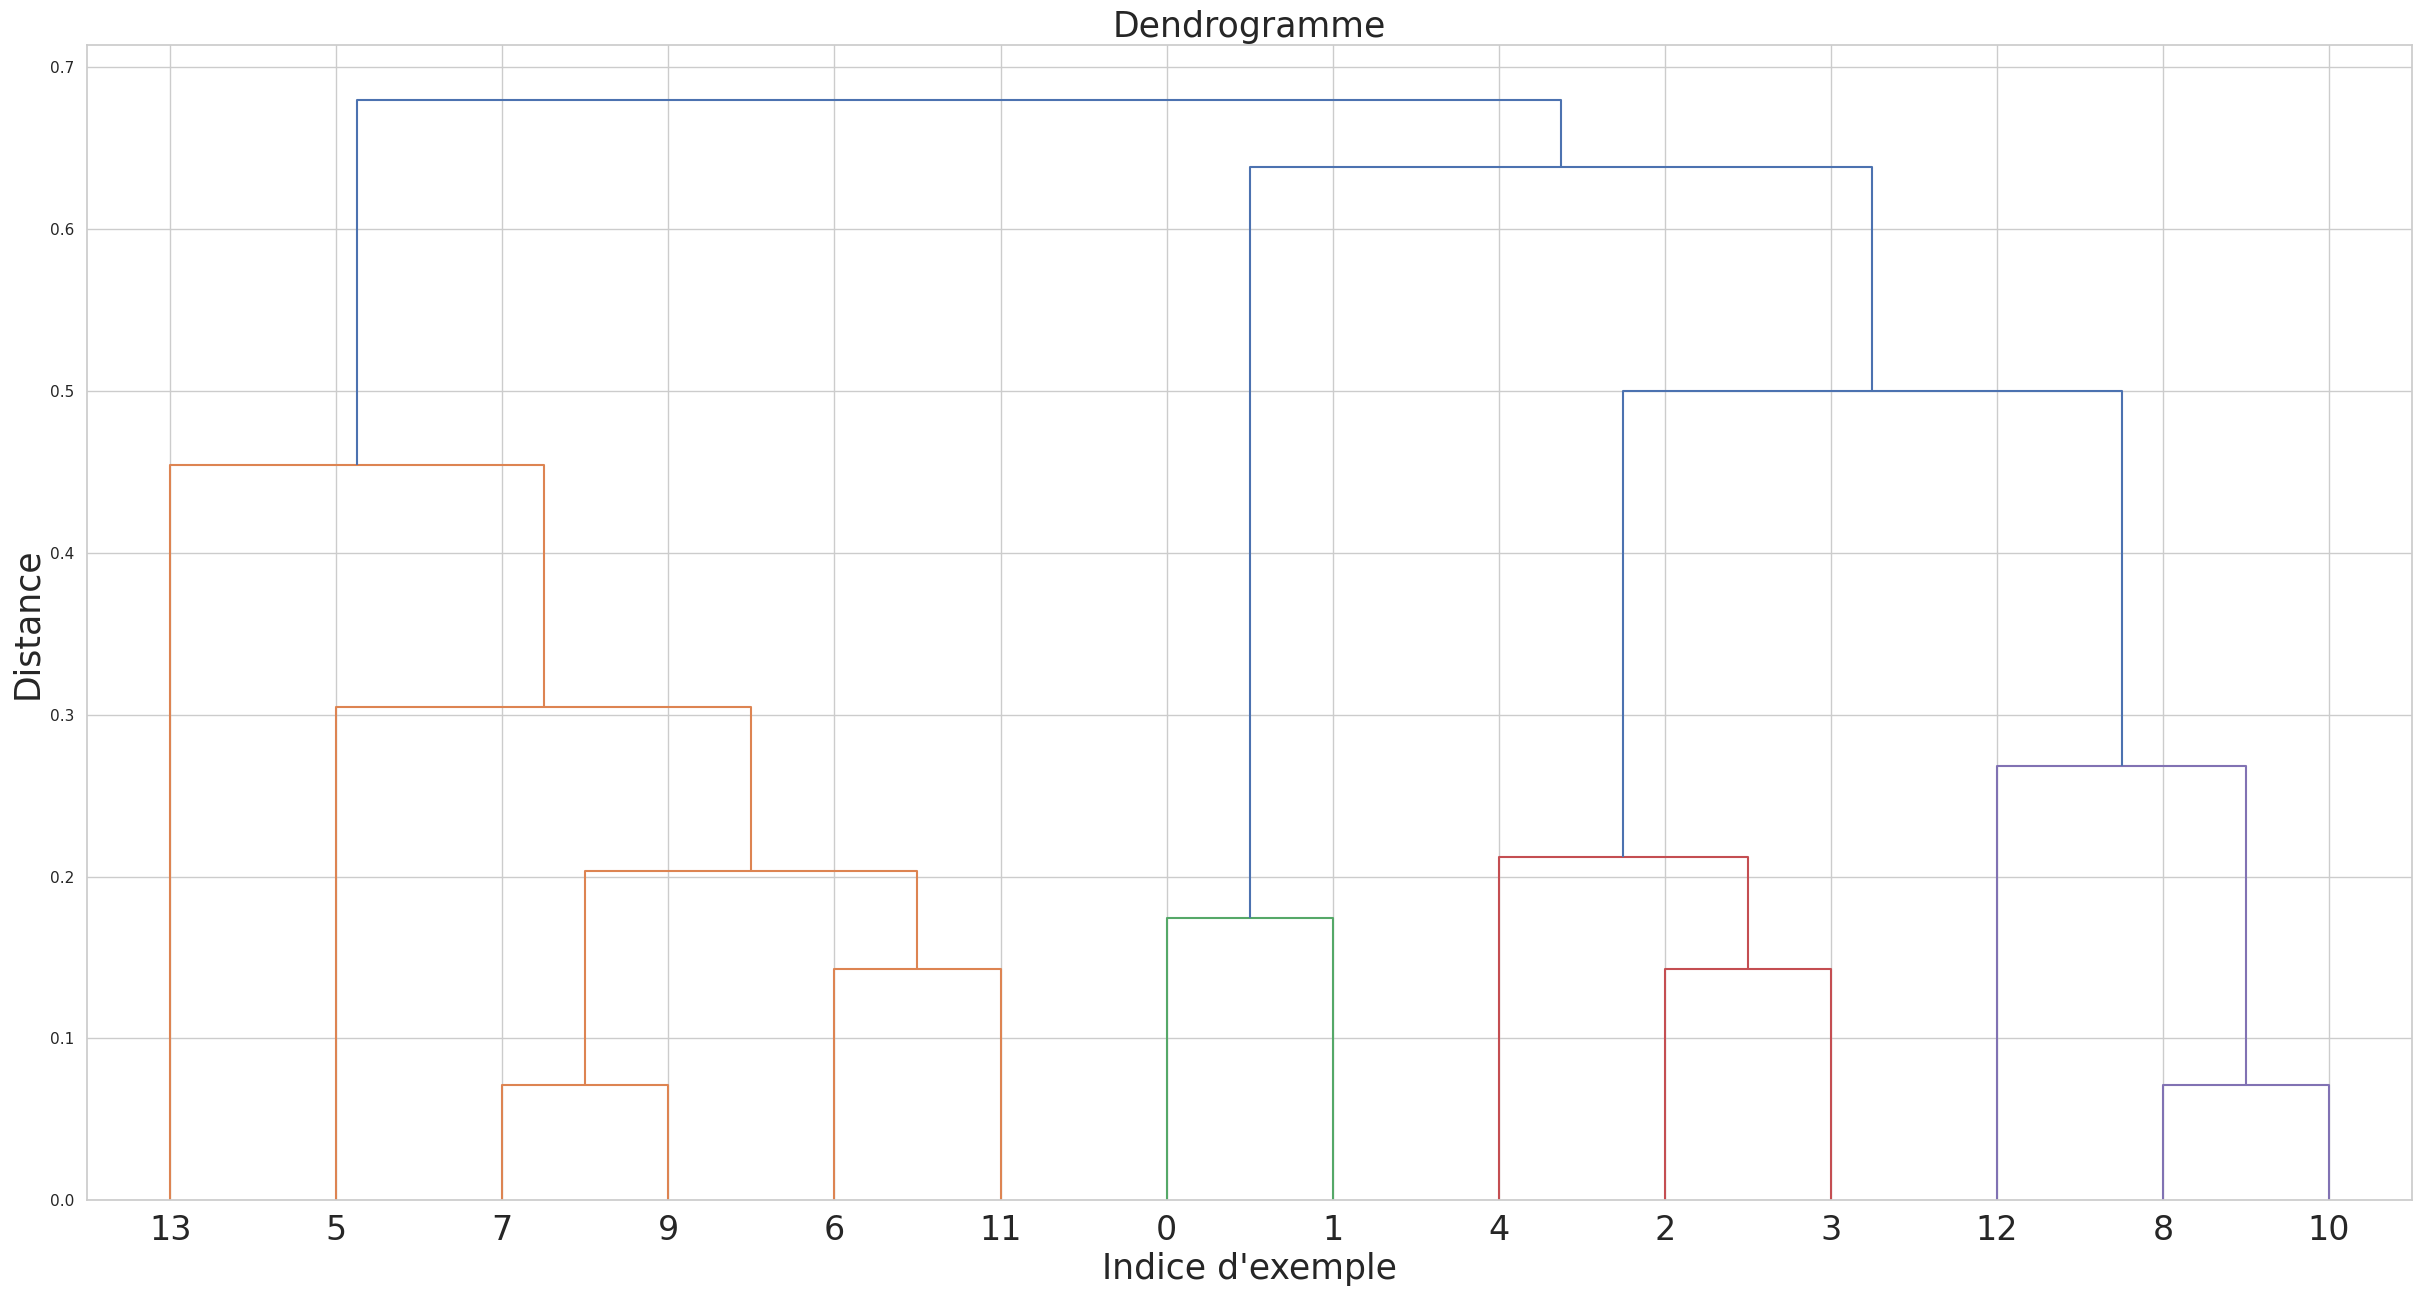

In [81]:
import scipy.cluster.hierarchy

# Paramètre de la fenêtre d'affichage: 
plt.figure(figsize=(30, 15)) # taille : largeur x hauteur
plt.title('Dendrogramme', fontsize=25)    
plt.xlabel("Indice d'exemple", fontsize=25)
plt.ylabel('Distance', fontsize=25)

# Construction du dendrogramme pour notre clustering :
scipy.cluster.hierarchy.dendrogram(
    CHA_centroid(data_2D_norm), 
    leaf_font_size=24. # taille des caractères de l'axe des X
)

# Affichage du résultat obtenu:
plt.show()

<font size="+1" color="RED"><b>[Q]</b></font> Modifier la fonction <code>CHA_centroid</code> en lui rajoutant un argument supplémentaire avec valeur par défaut:
- `dendrogramme=False` pour indiquer si on souhaite ou pas l'affichage du dendrogramme résultat. Si c'est le cas, le dendrogramme sera donc afficher à l'issue de la fonction.

In [84]:
import scipy.cluster.hierarchy


In [85]:
CHA_centroid(data_2D_norm)

array([[ 8.        , 10.        ,  0.07142857,  2.        ],
       [ 7.        ,  9.        ,  0.07142857,  2.        ],
       [ 2.        ,  3.        ,  0.14285714,  2.        ],
       [ 6.        , 11.        ,  0.14285714,  2.        ],
       [ 0.        ,  1.        ,  0.17437937,  2.        ],
       [15.        , 17.        ,  0.20316375,  4.        ],
       [ 4.        , 16.        ,  0.21237241,  3.        ],
       [12.        , 14.        ,  0.26811892,  3.        ],
       [ 5.        , 19.        ,  0.30474563,  5.        ],
       [13.        , 22.        ,  0.45428571,  6.        ],
       [20.        , 21.        ,  0.5       ,  6.        ],
       [18.        , 24.        ,  0.63813966,  8.        ],
       [23.        , 25.        ,  0.67968424, 14.        ]])

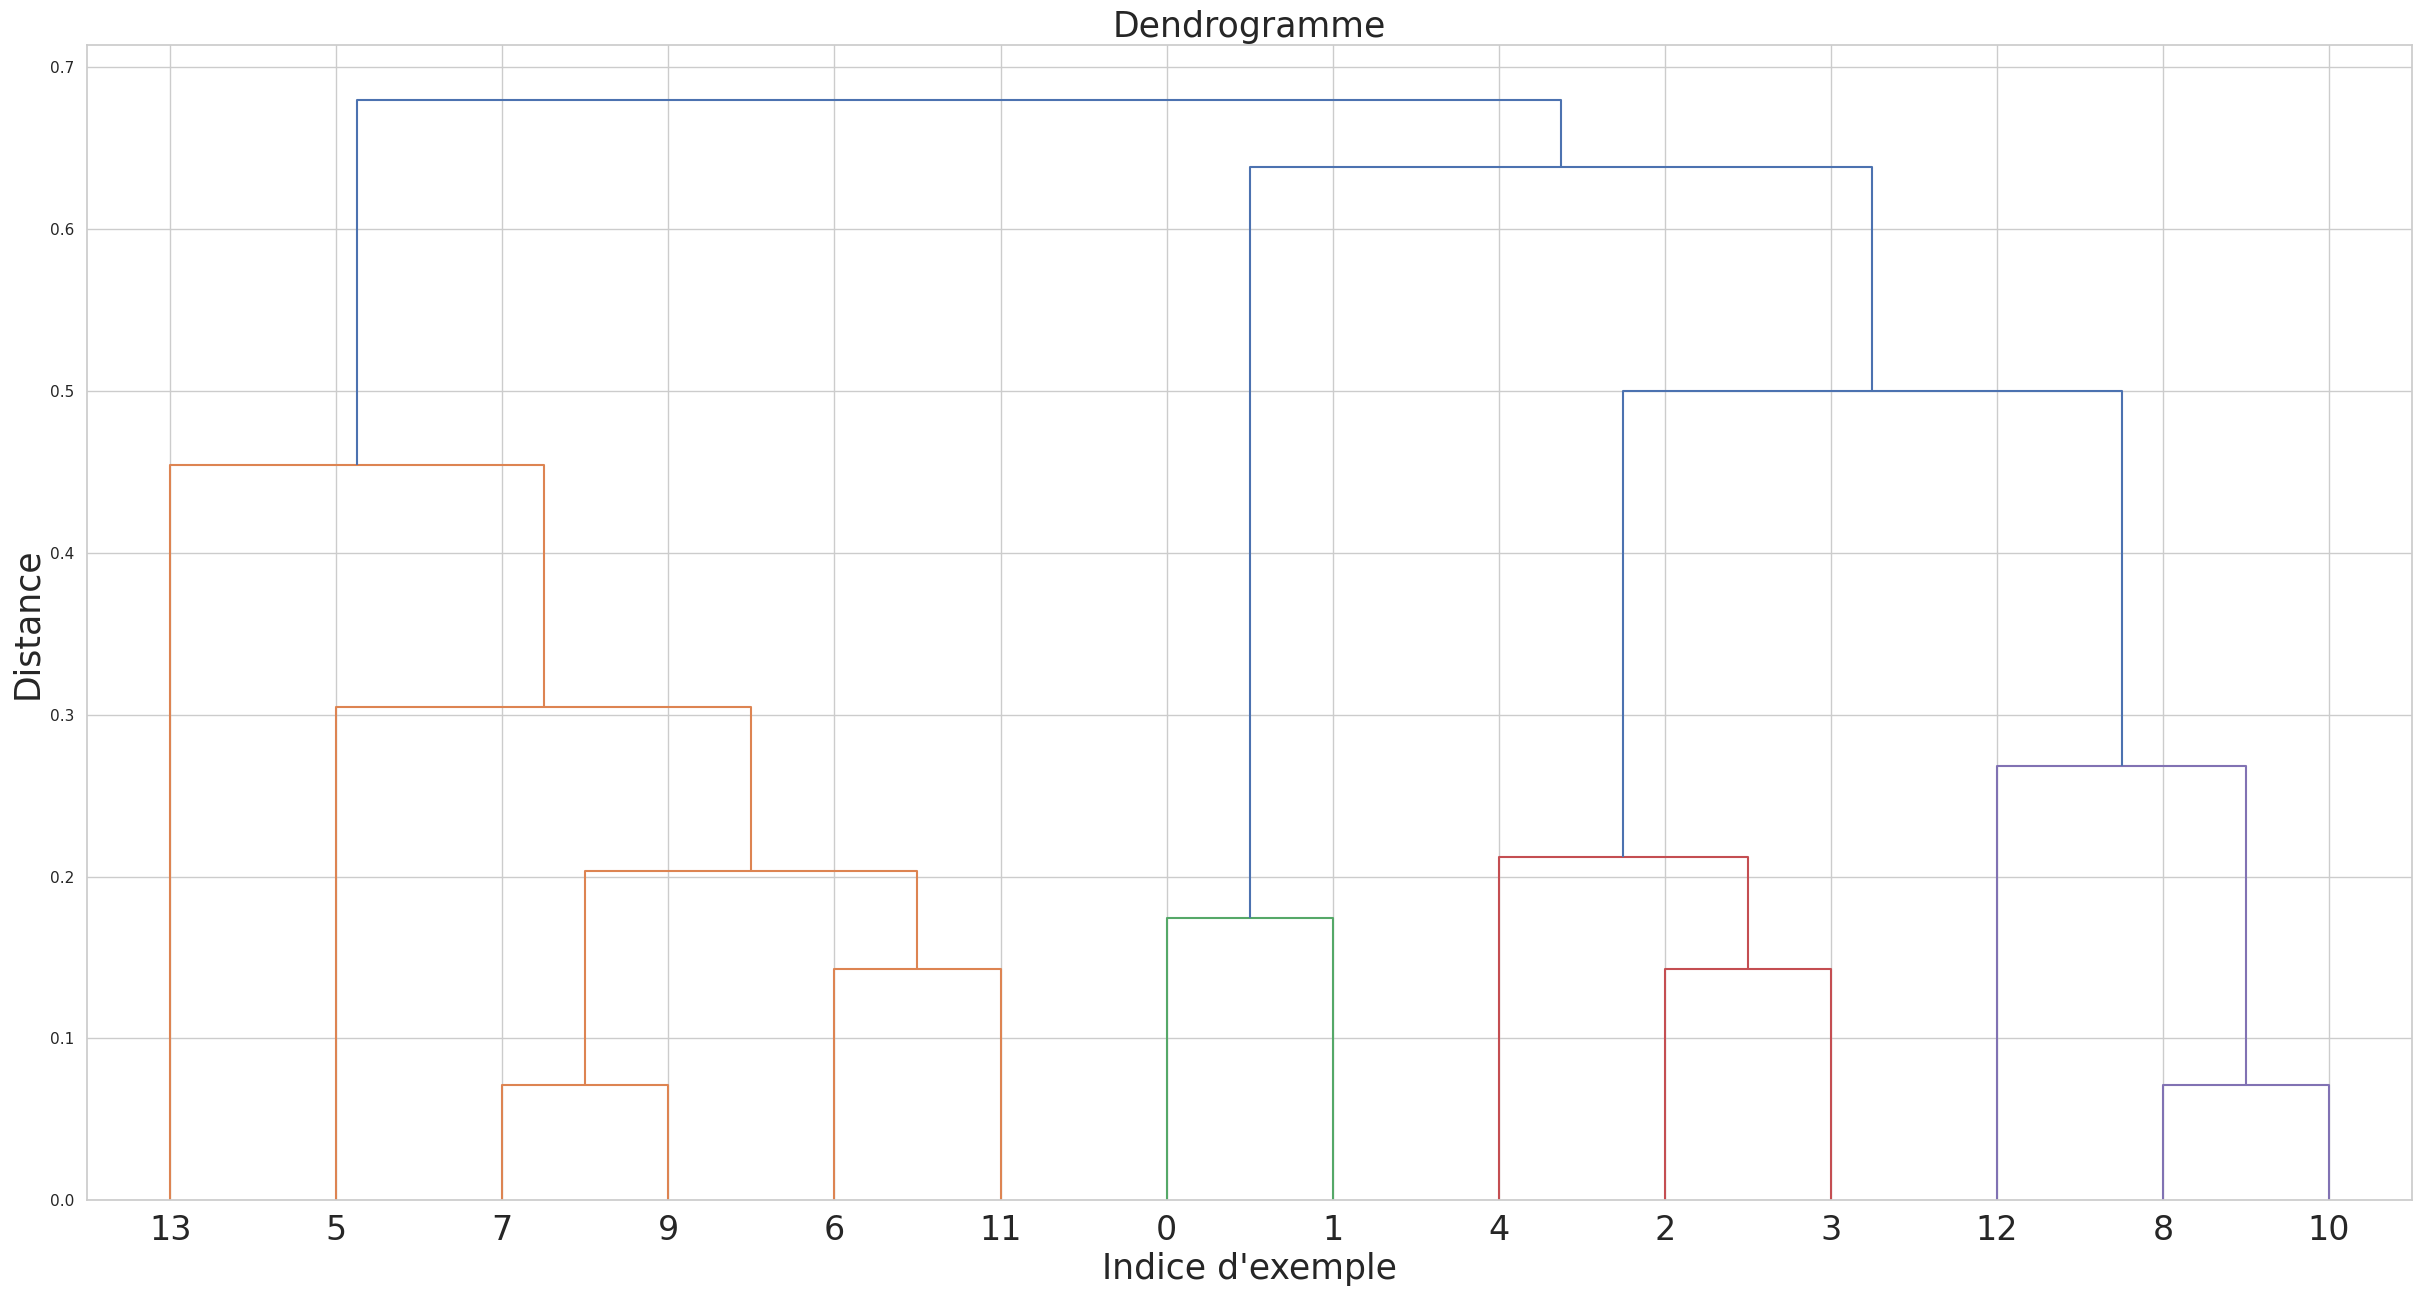

array([[ 8.        , 10.        ,  0.07142857,  2.        ],
       [ 7.        ,  9.        ,  0.07142857,  2.        ],
       [ 2.        ,  3.        ,  0.14285714,  2.        ],
       [ 6.        , 11.        ,  0.14285714,  2.        ],
       [ 0.        ,  1.        ,  0.17437937,  2.        ],
       [15.        , 17.        ,  0.20316375,  4.        ],
       [ 4.        , 16.        ,  0.21237241,  3.        ],
       [12.        , 14.        ,  0.26811892,  3.        ],
       [ 5.        , 19.        ,  0.30474563,  5.        ],
       [13.        , 22.        ,  0.45428571,  6.        ],
       [20.        , 21.        ,  0.5       ,  6.        ],
       [18.        , 24.        ,  0.63813966,  8.        ],
       [23.        , 25.        ,  0.67968424, 14.        ]])

In [86]:
CHA_centroid(data_2D_norm,dendrogramme=True)

### Variantes : complete linkage, simple linkage, average linkage

<font size="+1" color="RED"><b>[Q]</b></font> Ecrire 3 nouvelles fonctions `CHA_complete`, `CHA_simple` et `CHA_average` qui implémentent le clustering hiérarchique basé le linkage correspondant.


Puis afficher et comparer les dendrogrammes obtenus par les 4 approches de clustering implémentées.

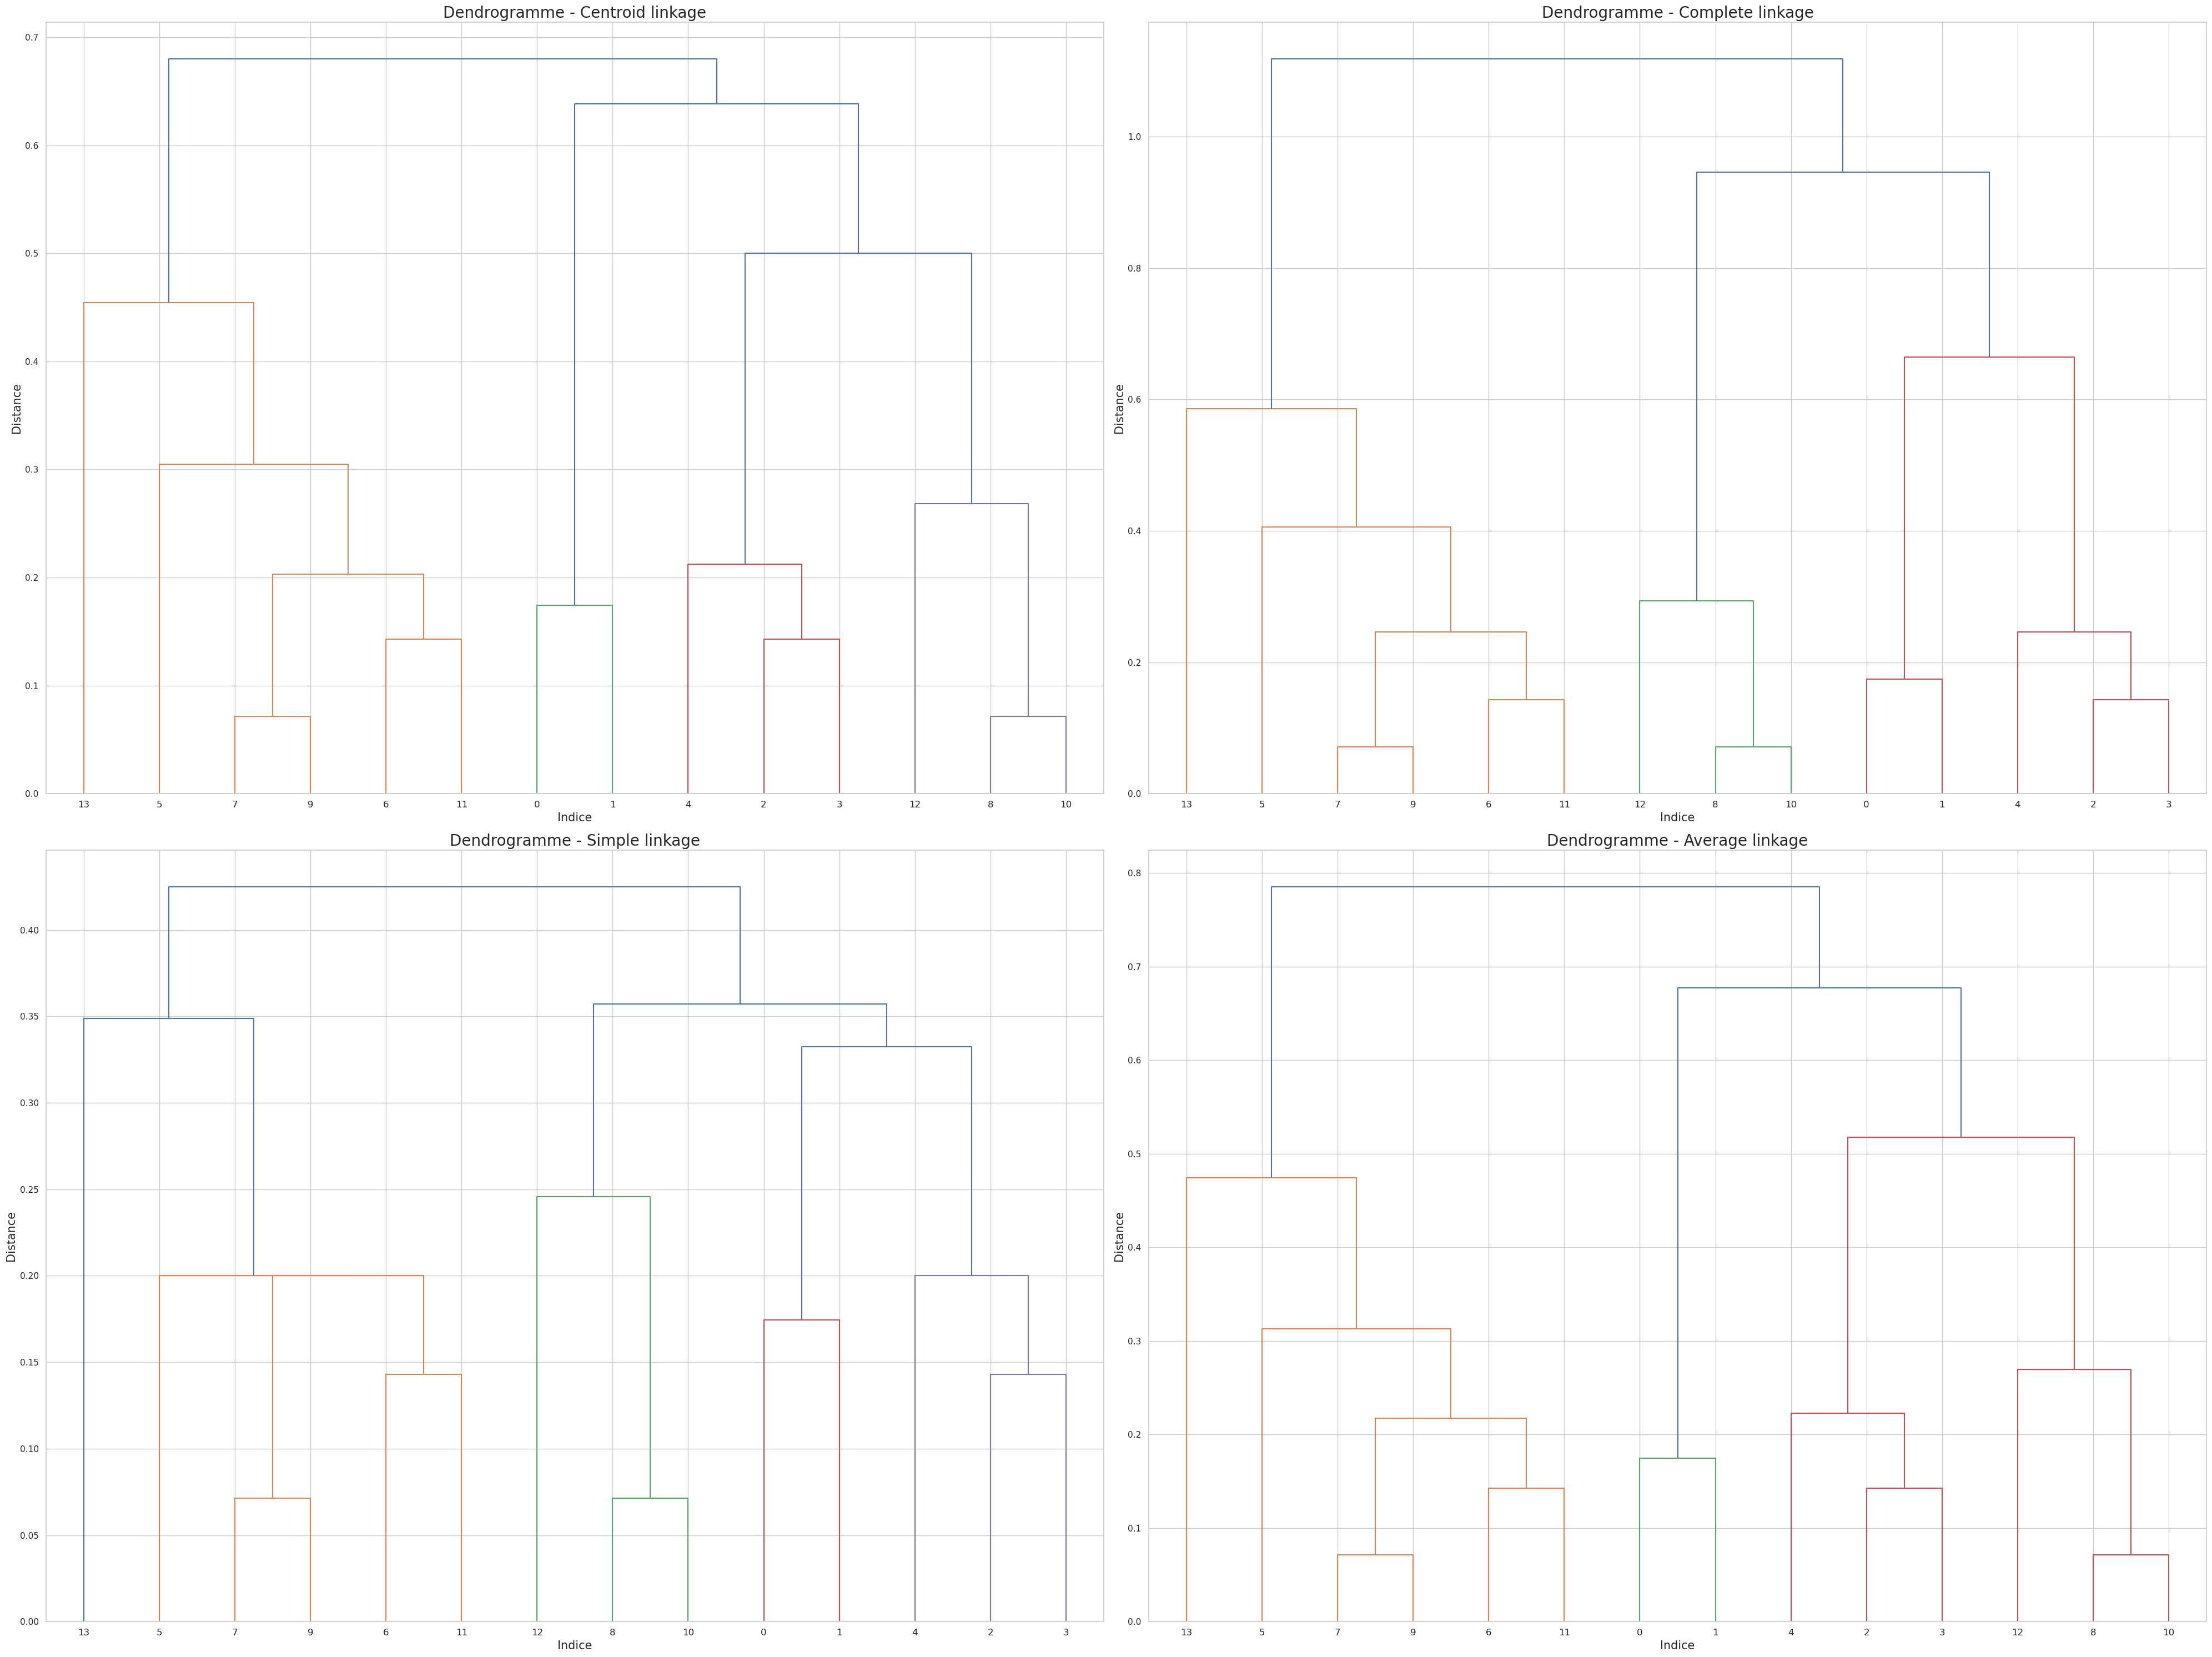

In [96]:
from scipy.spatial.distance import cdist

def dist_simple(cluster1, cluster2):
    """Distance minimale (single linkage)"""
    return np.min(cdist(cluster1, cluster2))

def dist_complete(cluster1, cluster2):
    """Distance maximale (complete linkage)"""
    return np.max(cdist(cluster1, cluster2))

def dist_average(cluster1, cluster2):
    """Distance moyenne (average linkage)"""
    return np.mean(cdist(cluster1, cluster2))


def CHA_linkage(DF, linkage_func, verbose=False, dendrogramme=False):
    """
    Clustering hiérarchique générique avec une fonction de linkage
    """
    partition = initialise_CHA(DF)
    fusion_results = []
    next_cluster_index = max(partition.keys()) + 1

    while len(partition) > 1:
        best_distance = float('inf')
        best_pair = (None, None)
        keys = list(partition.keys())

        for i in range(len(keys) - 1):
            for j in range(i + 1, len(keys)):
                key1 = keys[i]
                key2 = keys[j]
                cluster1 = DF.iloc[partition[key1]]
                cluster2 = DF.iloc[partition[key2]]
                d = linkage_func(cluster1.values, cluster2.values)
                if d < best_distance:
                    best_distance = d
                    best_pair = (key1, key2)

        cl1, cl2 = best_pair
        new_cluster = partition.pop(cl1) + partition.pop(cl2)
        partition[next_cluster_index] = new_cluster

        taille_total = len(new_cluster)
        fusion_results.append([cl1, cl2, best_distance, taille_total])
        if verbose:
            print(f"fusion des clusters {cl1} et {cl2} à distance {best_distance:.4f} (taille {taille_total})")

        next_cluster_index += 1

    linkage_matrix = np.array(fusion_results)

    if dendrogramme:
        plt.figure(figsize=(30, 15))
        plt.title('Dendrogramme', fontsize=25)
        plt.xlabel("Indice d'exemple", fontsize=25)
        plt.ylabel('Distance', fontsize=25)
        scipy.cluster.hierarchy.dendrogram(linkage_matrix, leaf_font_size=24.)
        plt.show()

    return linkage_matrix


def CHA_centroid(DF, verbose=False, dendrogramme=False):
    return CHA_linkage(DF, dist_centroides, verbose, dendrogramme)

def CHA_complete(DF, verbose=False, dendrogramme=False):
    return CHA_linkage(DF, dist_complete, verbose, dendrogramme)

def CHA_simple(DF, verbose=False, dendrogramme=False):
    return CHA_linkage(DF, dist_simple, verbose, dendrogramme)

def CHA_average(DF, verbose=False, dendrogramme=False):
    return CHA_linkage(DF, dist_average, verbose, dendrogramme)


linkage_methods = {
    "Centroid linkage": CHA_centroid,
    "Complete linkage": CHA_complete,
    "Simple linkage": CHA_simple,
    "Average linkage": CHA_average,
}

plt.figure(figsize=(40, 30))

for i, (name, func) in enumerate(linkage_methods.items(), 1):
    plt.subplot(2, 2, i)
    plt.title(f"Dendrogramme - {name}", fontsize=20)
    Z = func(data_2D_norm)
    scipy.cluster.hierarchy.dendrogram(Z, leaf_font_size=12.)
    plt.xlabel("Indice", fontsize=15)
    plt.ylabel("Distance", fontsize=15)

plt.tight_layout()
plt.show()



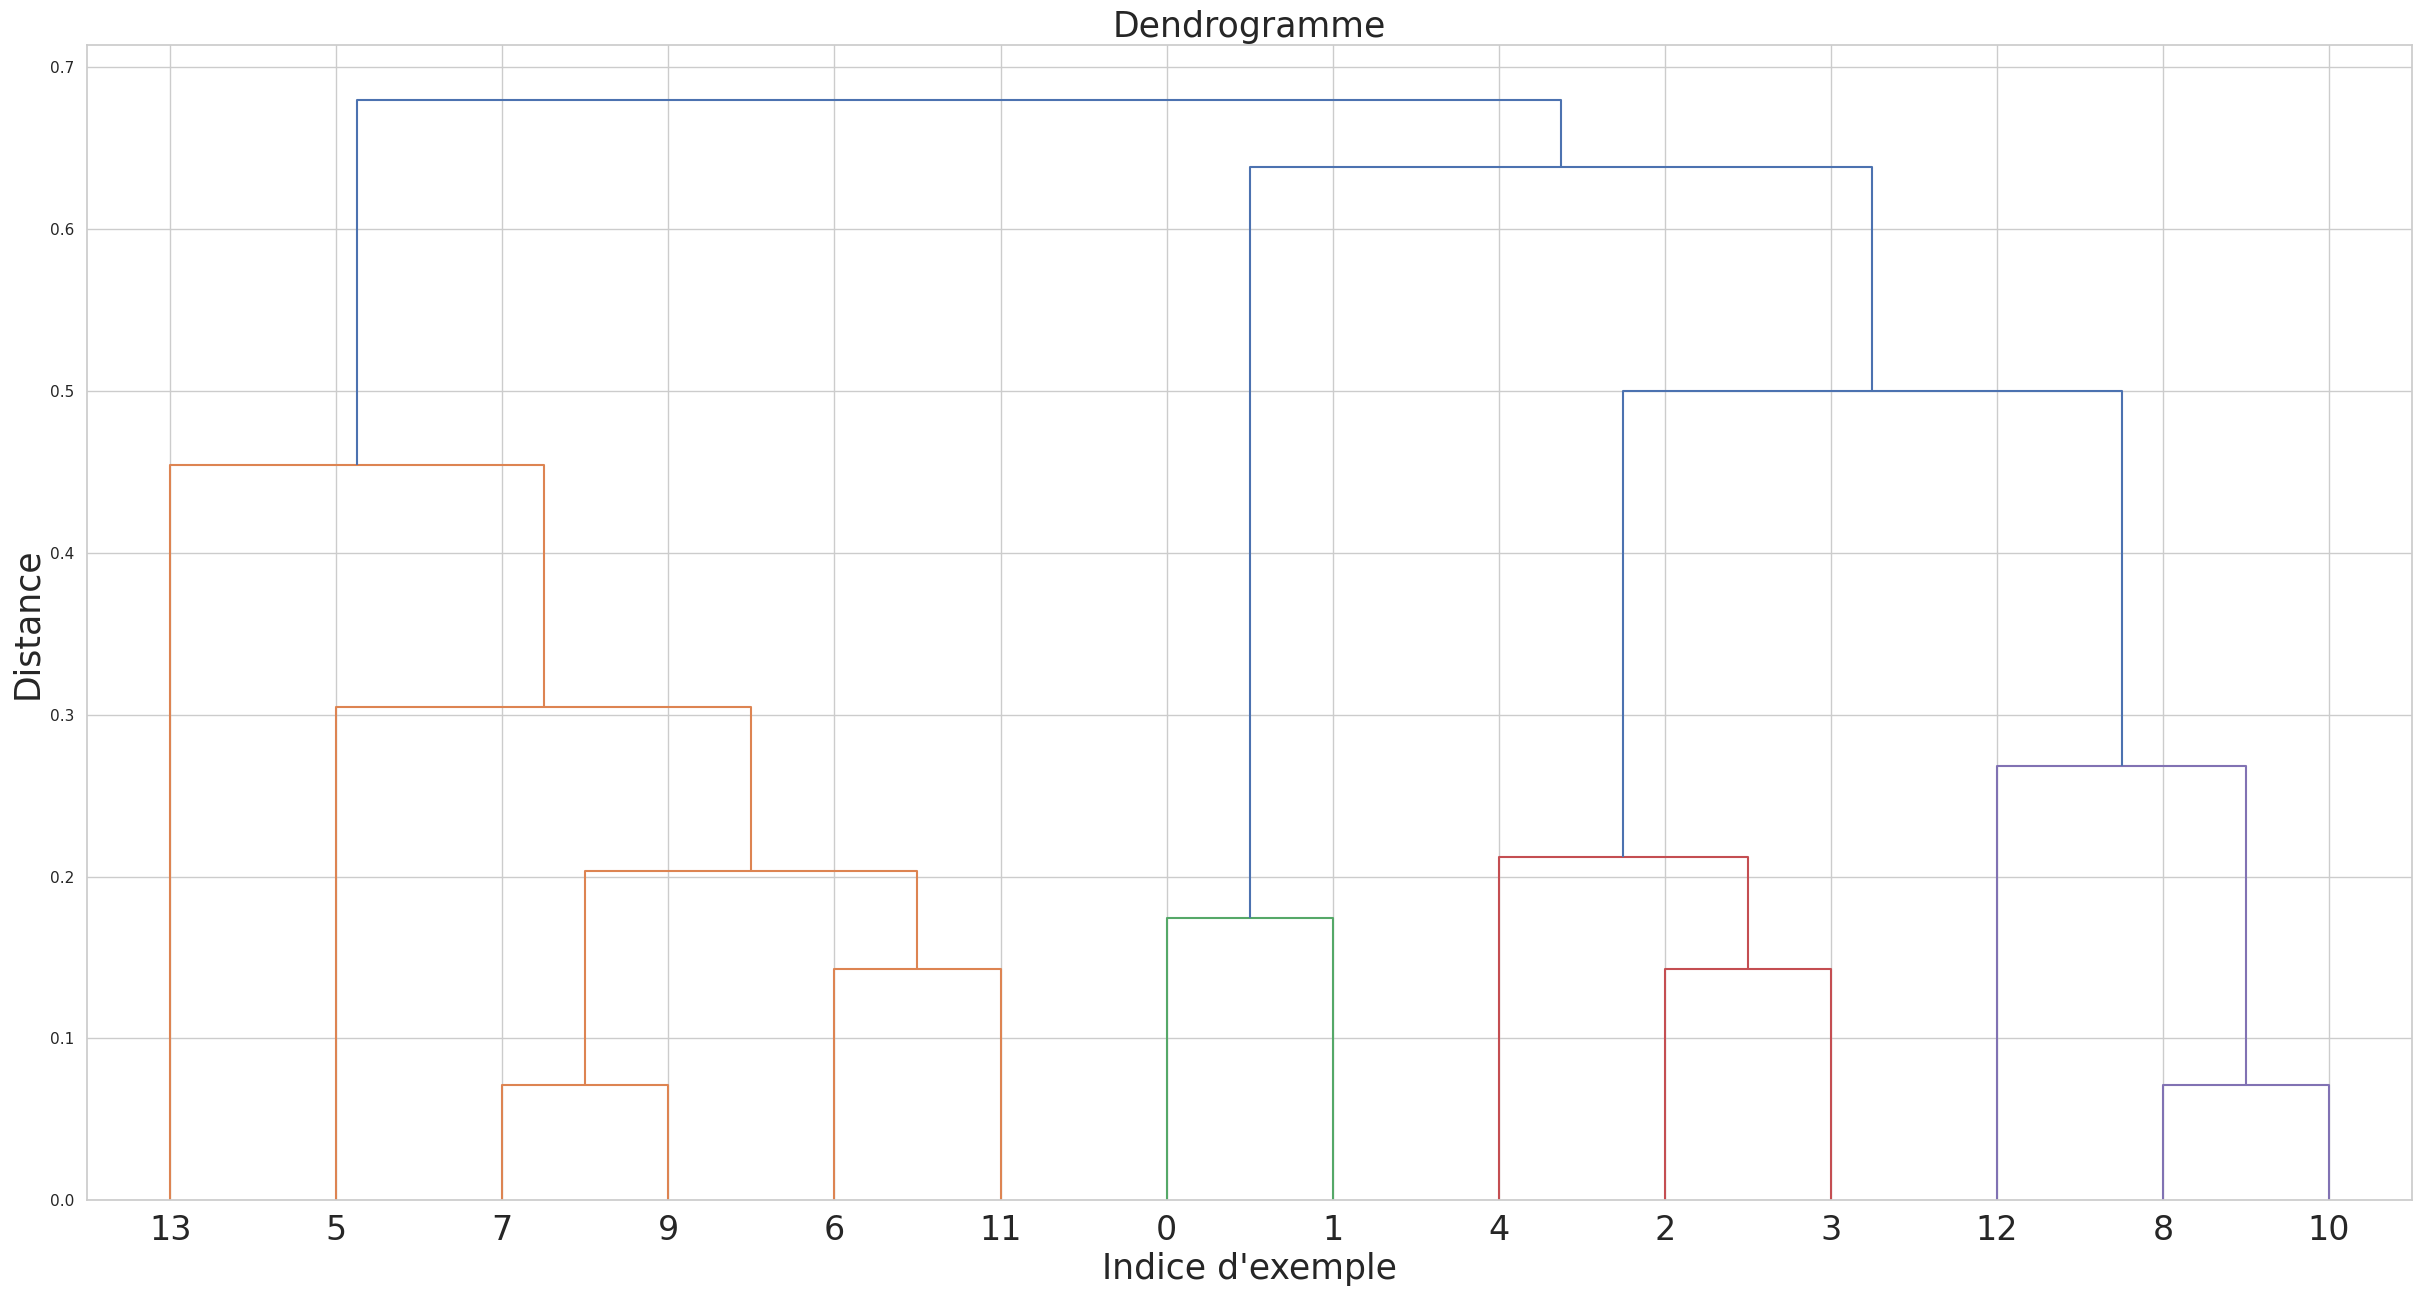

array([[ 8.        , 10.        ,  0.07142857,  2.        ],
       [ 7.        ,  9.        ,  0.07142857,  2.        ],
       [ 2.        ,  3.        ,  0.14285714,  2.        ],
       [ 6.        , 11.        ,  0.14285714,  2.        ],
       [ 0.        ,  1.        ,  0.17437937,  2.        ],
       [15.        , 17.        ,  0.20316375,  4.        ],
       [ 4.        , 16.        ,  0.21237241,  3.        ],
       [12.        , 14.        ,  0.26811892,  3.        ],
       [ 5.        , 19.        ,  0.30474563,  5.        ],
       [13.        , 22.        ,  0.45428571,  6.        ],
       [20.        , 21.        ,  0.5       ,  6.        ],
       [18.        , 24.        ,  0.63813966,  8.        ],
       [23.        , 25.        ,  0.67968424, 14.        ]])

In [90]:
CHA_centroid(data_2D_norm,dendrogramme=True)

<font size="+1" color="RED"><b>[Q]</b></font> Regrouper les 4 fonctions de clustering hiérarchique ascendant en écrivant une fonction `CHA` qui prend les mêmes arguments que chacune des 4 fonctions précédentes, et un argument suplémentaire `linkage`, qui est une chaîne de caractères parmi `"centroid"` (valeur par défaut),  `"complete"`,`"simple"`, et `"average"` et qui donne le nom de l'approche linkage à utiliser pour construire le clustering.

In [91]:
def CHA(DF,linkage='centroid', verbose=False,dendrogramme=False):
    """  ##### donner une documentation à cette fonction
    """
    ############################ A COMPLETER

    linkage_funcs = {
        'centroid': dist_centroides,
        'complete': dist_complete,
        'simple': dist_simple,
        'average': dist_average
    }

    if linkage not in linkage_funcs:
        raise ValueError(f"Méthode de linkage inconnue : '{linkage}'. Choisissez parmi {list(linkage_funcs.keys())}.")

    dist_func = linkage_funcs[linkage]
    partition = initialise_CHA(DF)
    fusion_results = []
    next_cluster_index = max(partition.keys()) + 1

    while len(partition) > 1:
        best_distance = float('inf')
        best_pair = (None, None)
        keys = list(partition.keys())

        for i in range(len(keys) - 1):
            for j in range(i + 1, len(keys)):
                key1 = keys[i]
                key2 = keys[j]
                cluster1 = DF.iloc[partition[key1]]
                cluster2 = DF.iloc[partition[key2]]
                d = dist_func(cluster1.values, cluster2.values)
                if d < best_distance:
                    best_distance = d
                    best_pair = (key1, key2)

        cl1, cl2 = best_pair
        new_cluster = partition.pop(cl1) + partition.pop(cl2)
        partition[next_cluster_index] = new_cluster

        taille_total = len(new_cluster)
        fusion_results.append([cl1, cl2, best_distance, taille_total])
        if verbose:
            print(f"fusion des clusters {cl1} et {cl2} à distance {best_distance:.4f} (taille {taille_total})")

        next_cluster_index += 1

    linkage_matrix = np.array(fusion_results)

    if dendrogramme:
        plt.figure(figsize=(30, 15))
        plt.title(f'Dendrogramme - {linkage.capitalize()} linkage', fontsize=25)
        plt.xlabel("Indice d'exemple", fontsize=25)
        plt.ylabel('Distance', fontsize=25)
        scipy.cluster.hierarchy.dendrogram(linkage_matrix, leaf_font_size=24.)
        plt.show()

    return linkage_matrix
    

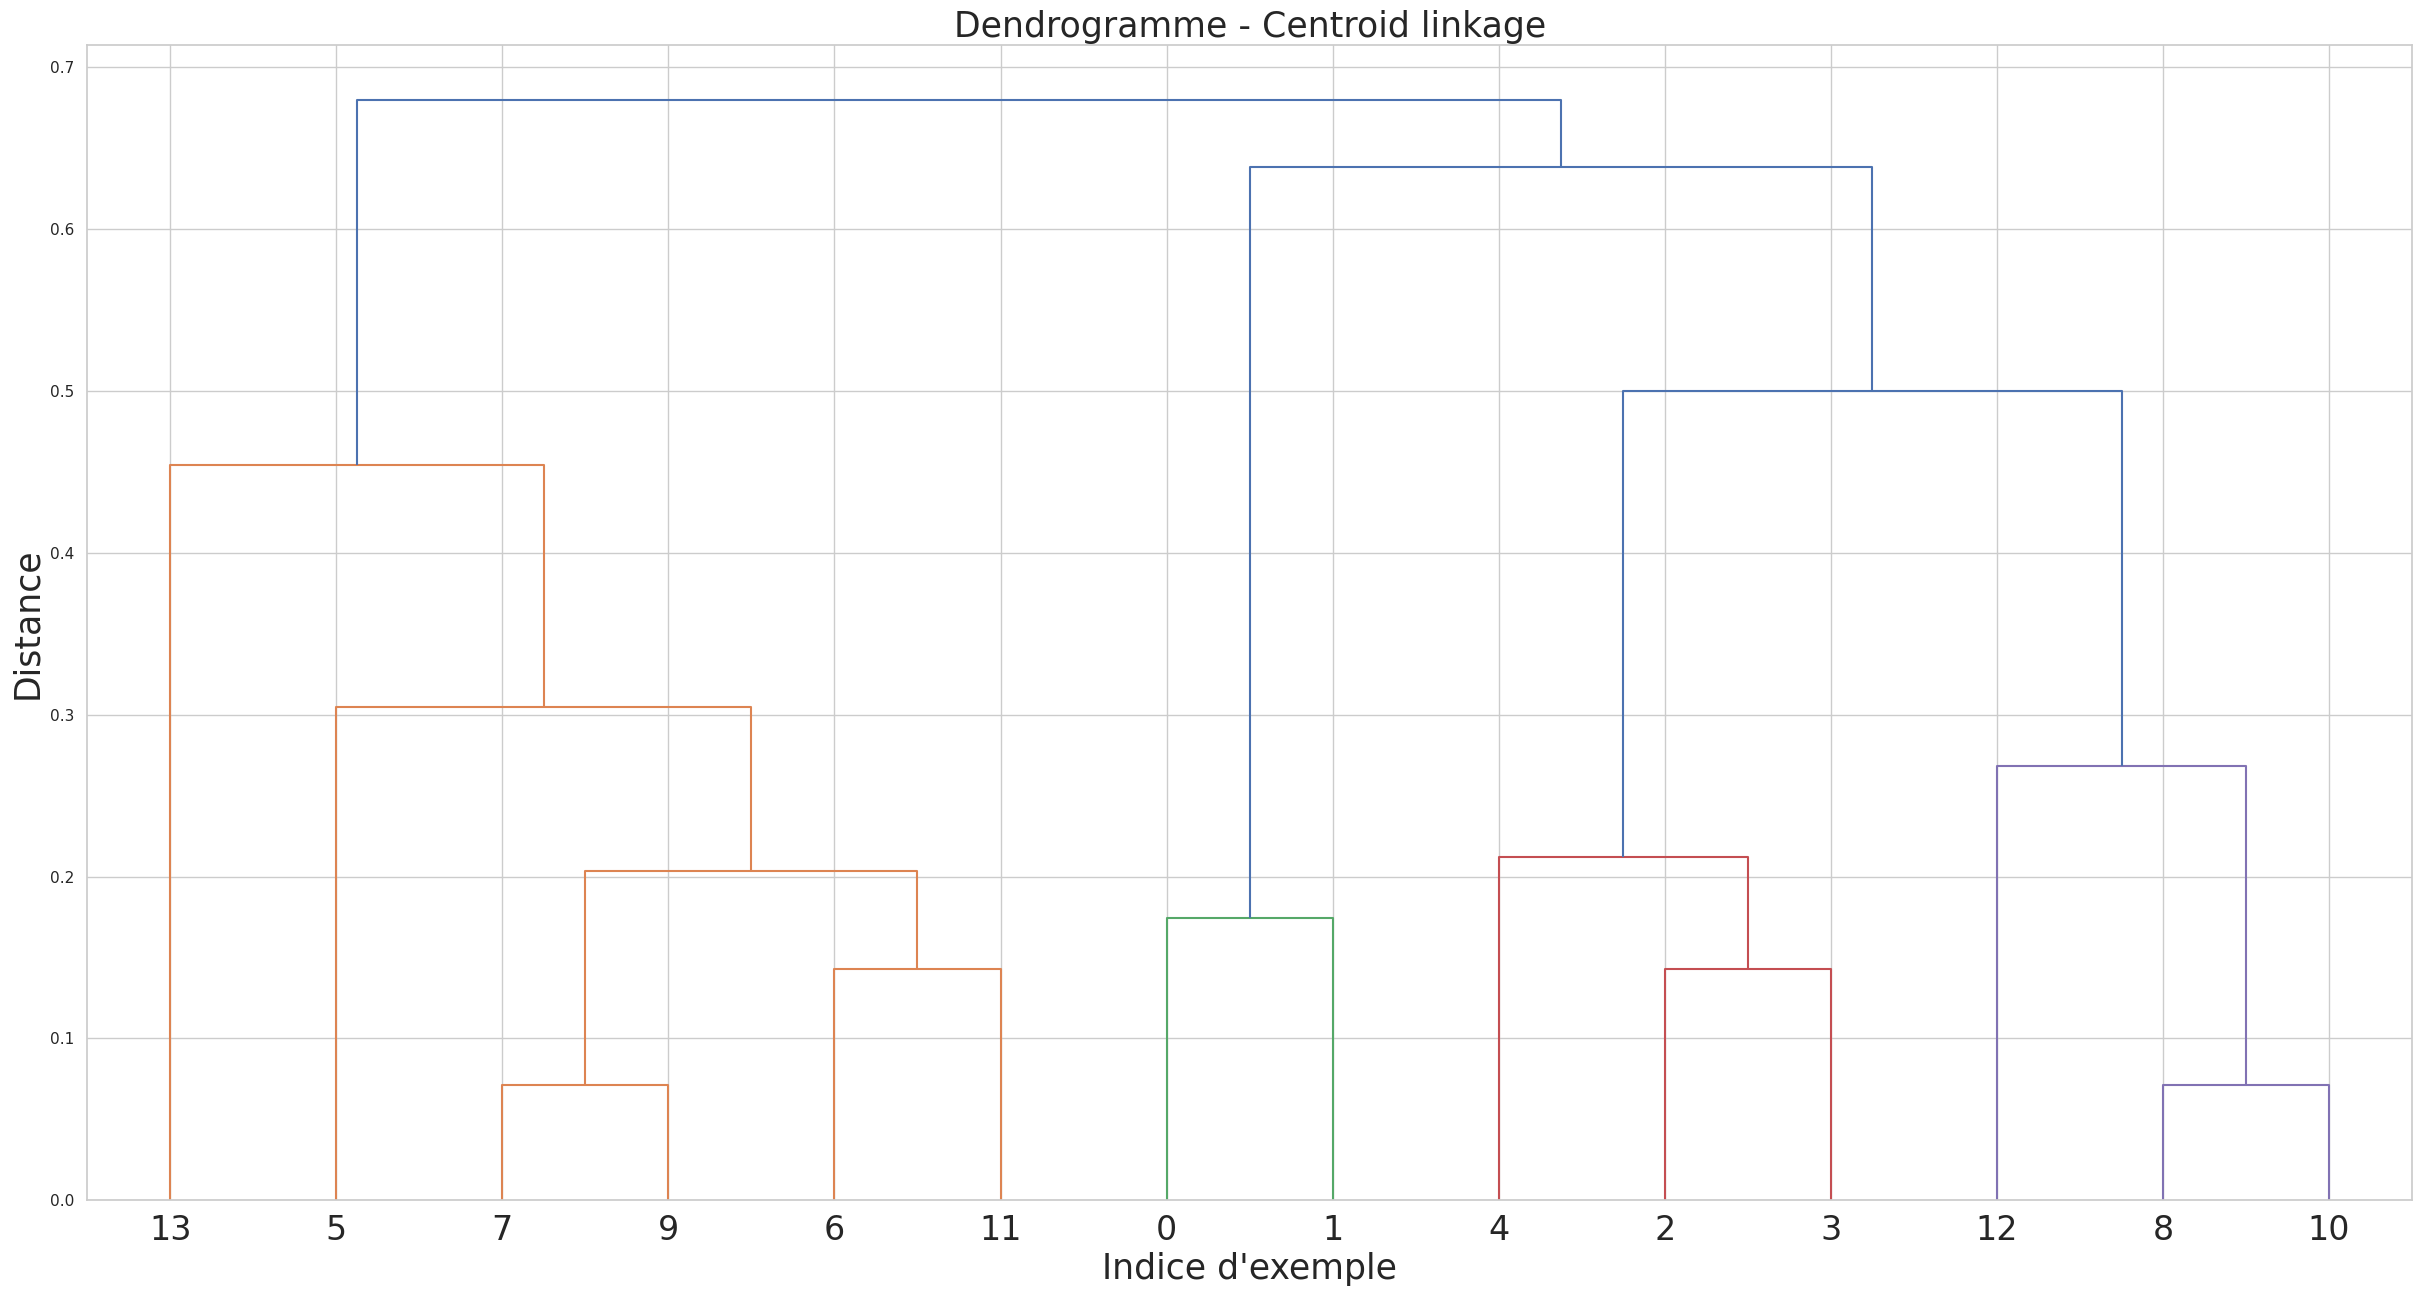

array([[ 8.        , 10.        ,  0.07142857,  2.        ],
       [ 7.        ,  9.        ,  0.07142857,  2.        ],
       [ 2.        ,  3.        ,  0.14285714,  2.        ],
       [ 6.        , 11.        ,  0.14285714,  2.        ],
       [ 0.        ,  1.        ,  0.17437937,  2.        ],
       [15.        , 17.        ,  0.20316375,  4.        ],
       [ 4.        , 16.        ,  0.21237241,  3.        ],
       [12.        , 14.        ,  0.26811892,  3.        ],
       [ 5.        , 19.        ,  0.30474563,  5.        ],
       [13.        , 22.        ,  0.45428571,  6.        ],
       [20.        , 21.        ,  0.5       ,  6.        ],
       [18.        , 24.        ,  0.63813966,  8.        ],
       [23.        , 25.        ,  0.67968424, 14.        ]])

In [92]:
CHA(data_2D_norm,linkage='centroid',dendrogramme=True)

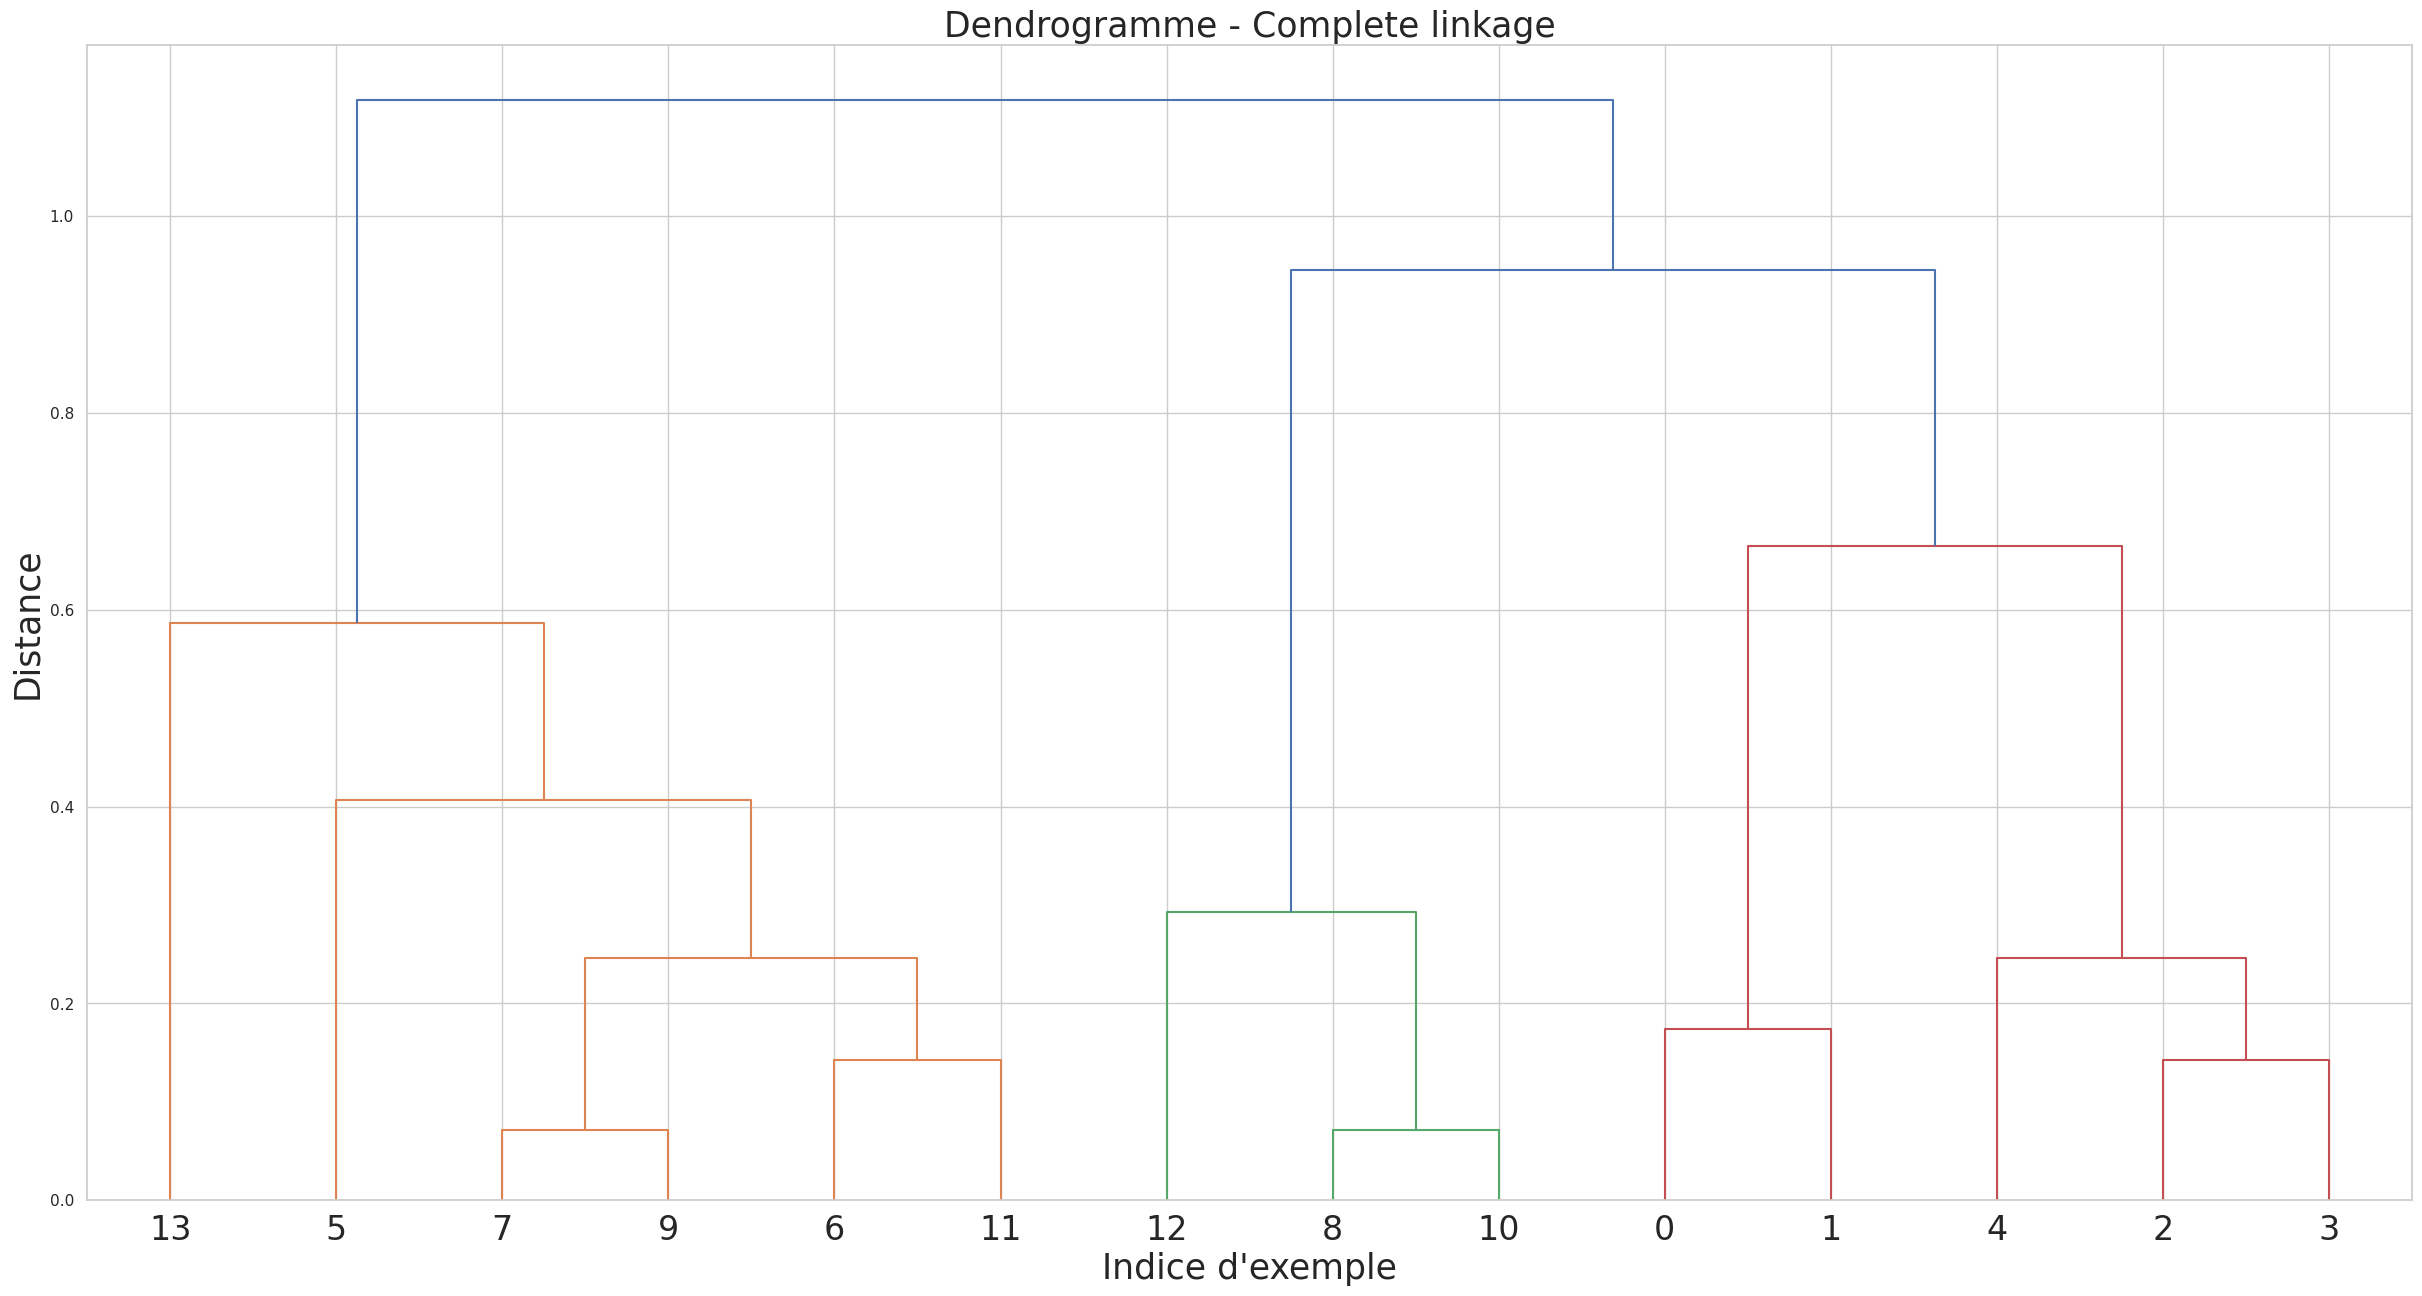

array([[ 8.        , 10.        ,  0.07142857,  2.        ],
       [ 7.        ,  9.        ,  0.07142857,  2.        ],
       [ 2.        ,  3.        ,  0.14285714,  2.        ],
       [ 6.        , 11.        ,  0.14285714,  2.        ],
       [ 0.        ,  1.        ,  0.17437937,  2.        ],
       [15.        , 17.        ,  0.24578072,  4.        ],
       [ 4.        , 16.        ,  0.24578072,  3.        ],
       [12.        , 14.        ,  0.29311835,  3.        ],
       [ 5.        , 19.        ,  0.4063275 ,  5.        ],
       [13.        , 22.        ,  0.5862367 ,  6.        ],
       [18.        , 20.        ,  0.66455448,  5.        ],
       [21.        , 24.        ,  0.94588259,  8.        ],
       [23.        , 25.        ,  1.11803399, 14.        ]])

In [93]:
CHA(data_2D_norm,linkage='complete',dendrogramme=True)

fusion des clusters 8 et 10 à distance 0.0714 (taille 2)
fusion des clusters 7 et 9 à distance 0.0714 (taille 2)
fusion des clusters 2 et 3 à distance 0.1429 (taille 2)
fusion des clusters 6 et 11 à distance 0.1429 (taille 2)
fusion des clusters 0 et 1 à distance 0.1744 (taille 2)
fusion des clusters 15 et 17 à distance 0.2000 (taille 4)
fusion des clusters 4 et 16 à distance 0.2000 (taille 3)
fusion des clusters 5 et 19 à distance 0.2000 (taille 5)
fusion des clusters 12 et 14 à distance 0.2458 (taille 3)
fusion des clusters 18 et 20 à distance 0.3323 (taille 5)
fusion des clusters 13 et 21 à distance 0.3488 (taille 6)
fusion des clusters 22 et 23 à distance 0.3571 (taille 8)
fusion des clusters 24 et 25 à distance 0.4247 (taille 14)


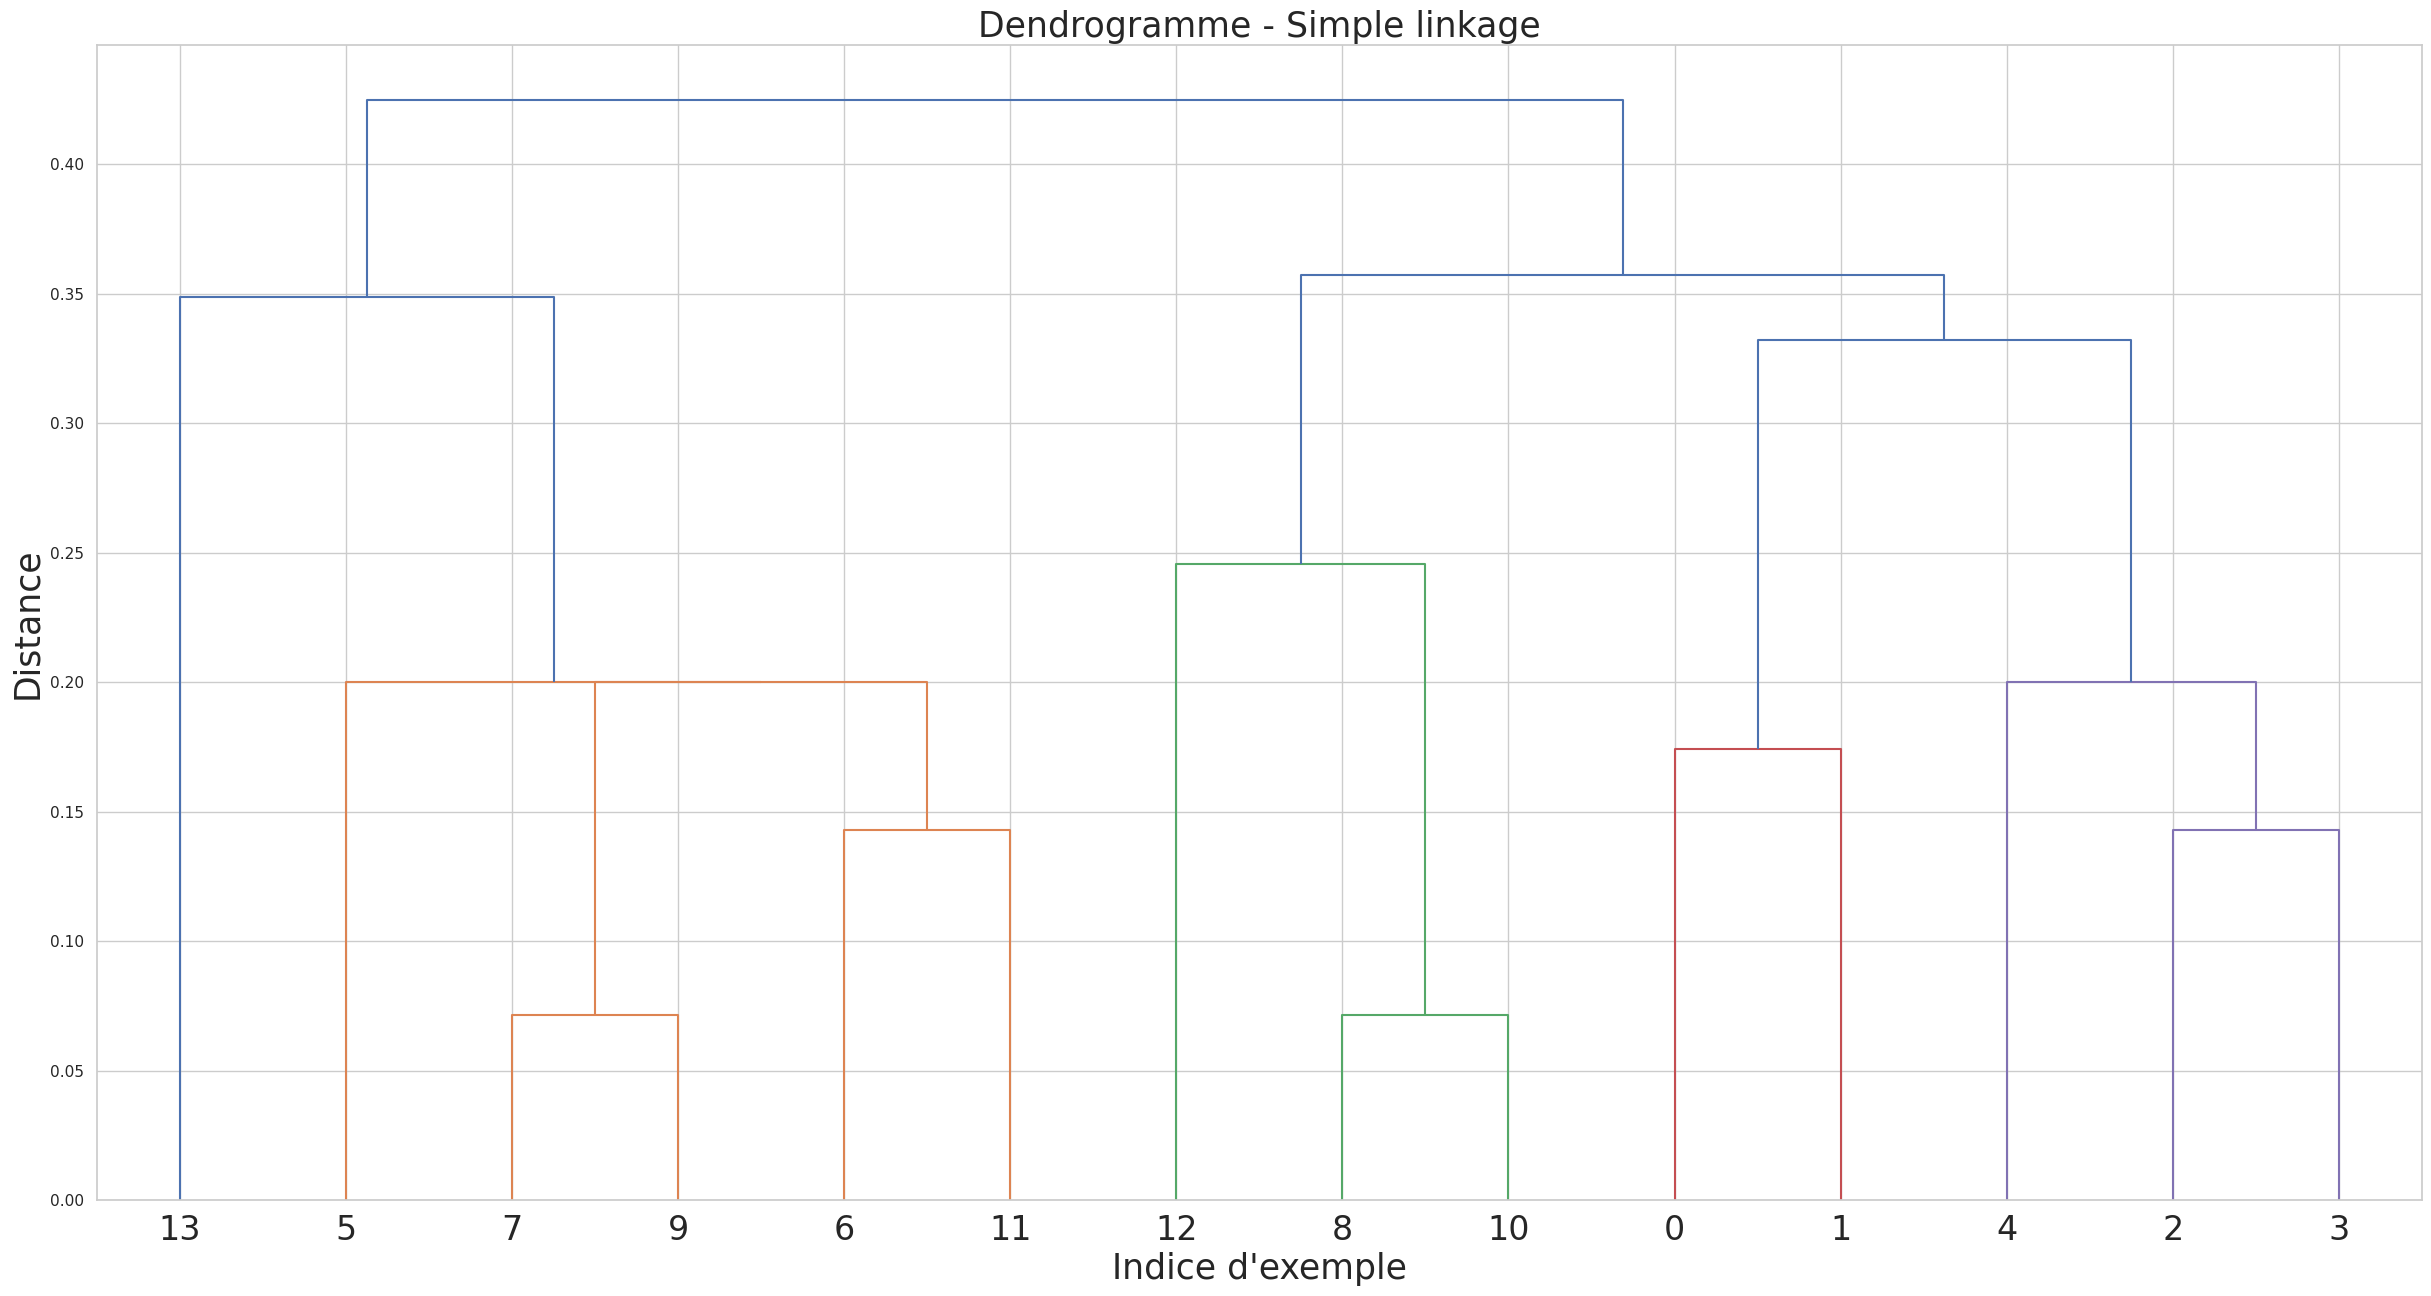

array([[ 8.        , 10.        ,  0.07142857,  2.        ],
       [ 7.        ,  9.        ,  0.07142857,  2.        ],
       [ 2.        ,  3.        ,  0.14285714,  2.        ],
       [ 6.        , 11.        ,  0.14285714,  2.        ],
       [ 0.        ,  1.        ,  0.17437937,  2.        ],
       [15.        , 17.        ,  0.2       ,  4.        ],
       [ 4.        , 16.        ,  0.2       ,  3.        ],
       [ 5.        , 19.        ,  0.2       ,  5.        ],
       [12.        , 14.        ,  0.24578072,  3.        ],
       [18.        , 20.        ,  0.33227724,  5.        ],
       [13.        , 21.        ,  0.34875873,  6.        ],
       [22.        , 23.        ,  0.35714286,  8.        ],
       [24.        , 25.        ,  0.42474482, 14.        ]])

In [94]:
CHA(data_2D_norm,linkage='simple',verbose=True,dendrogramme=True)

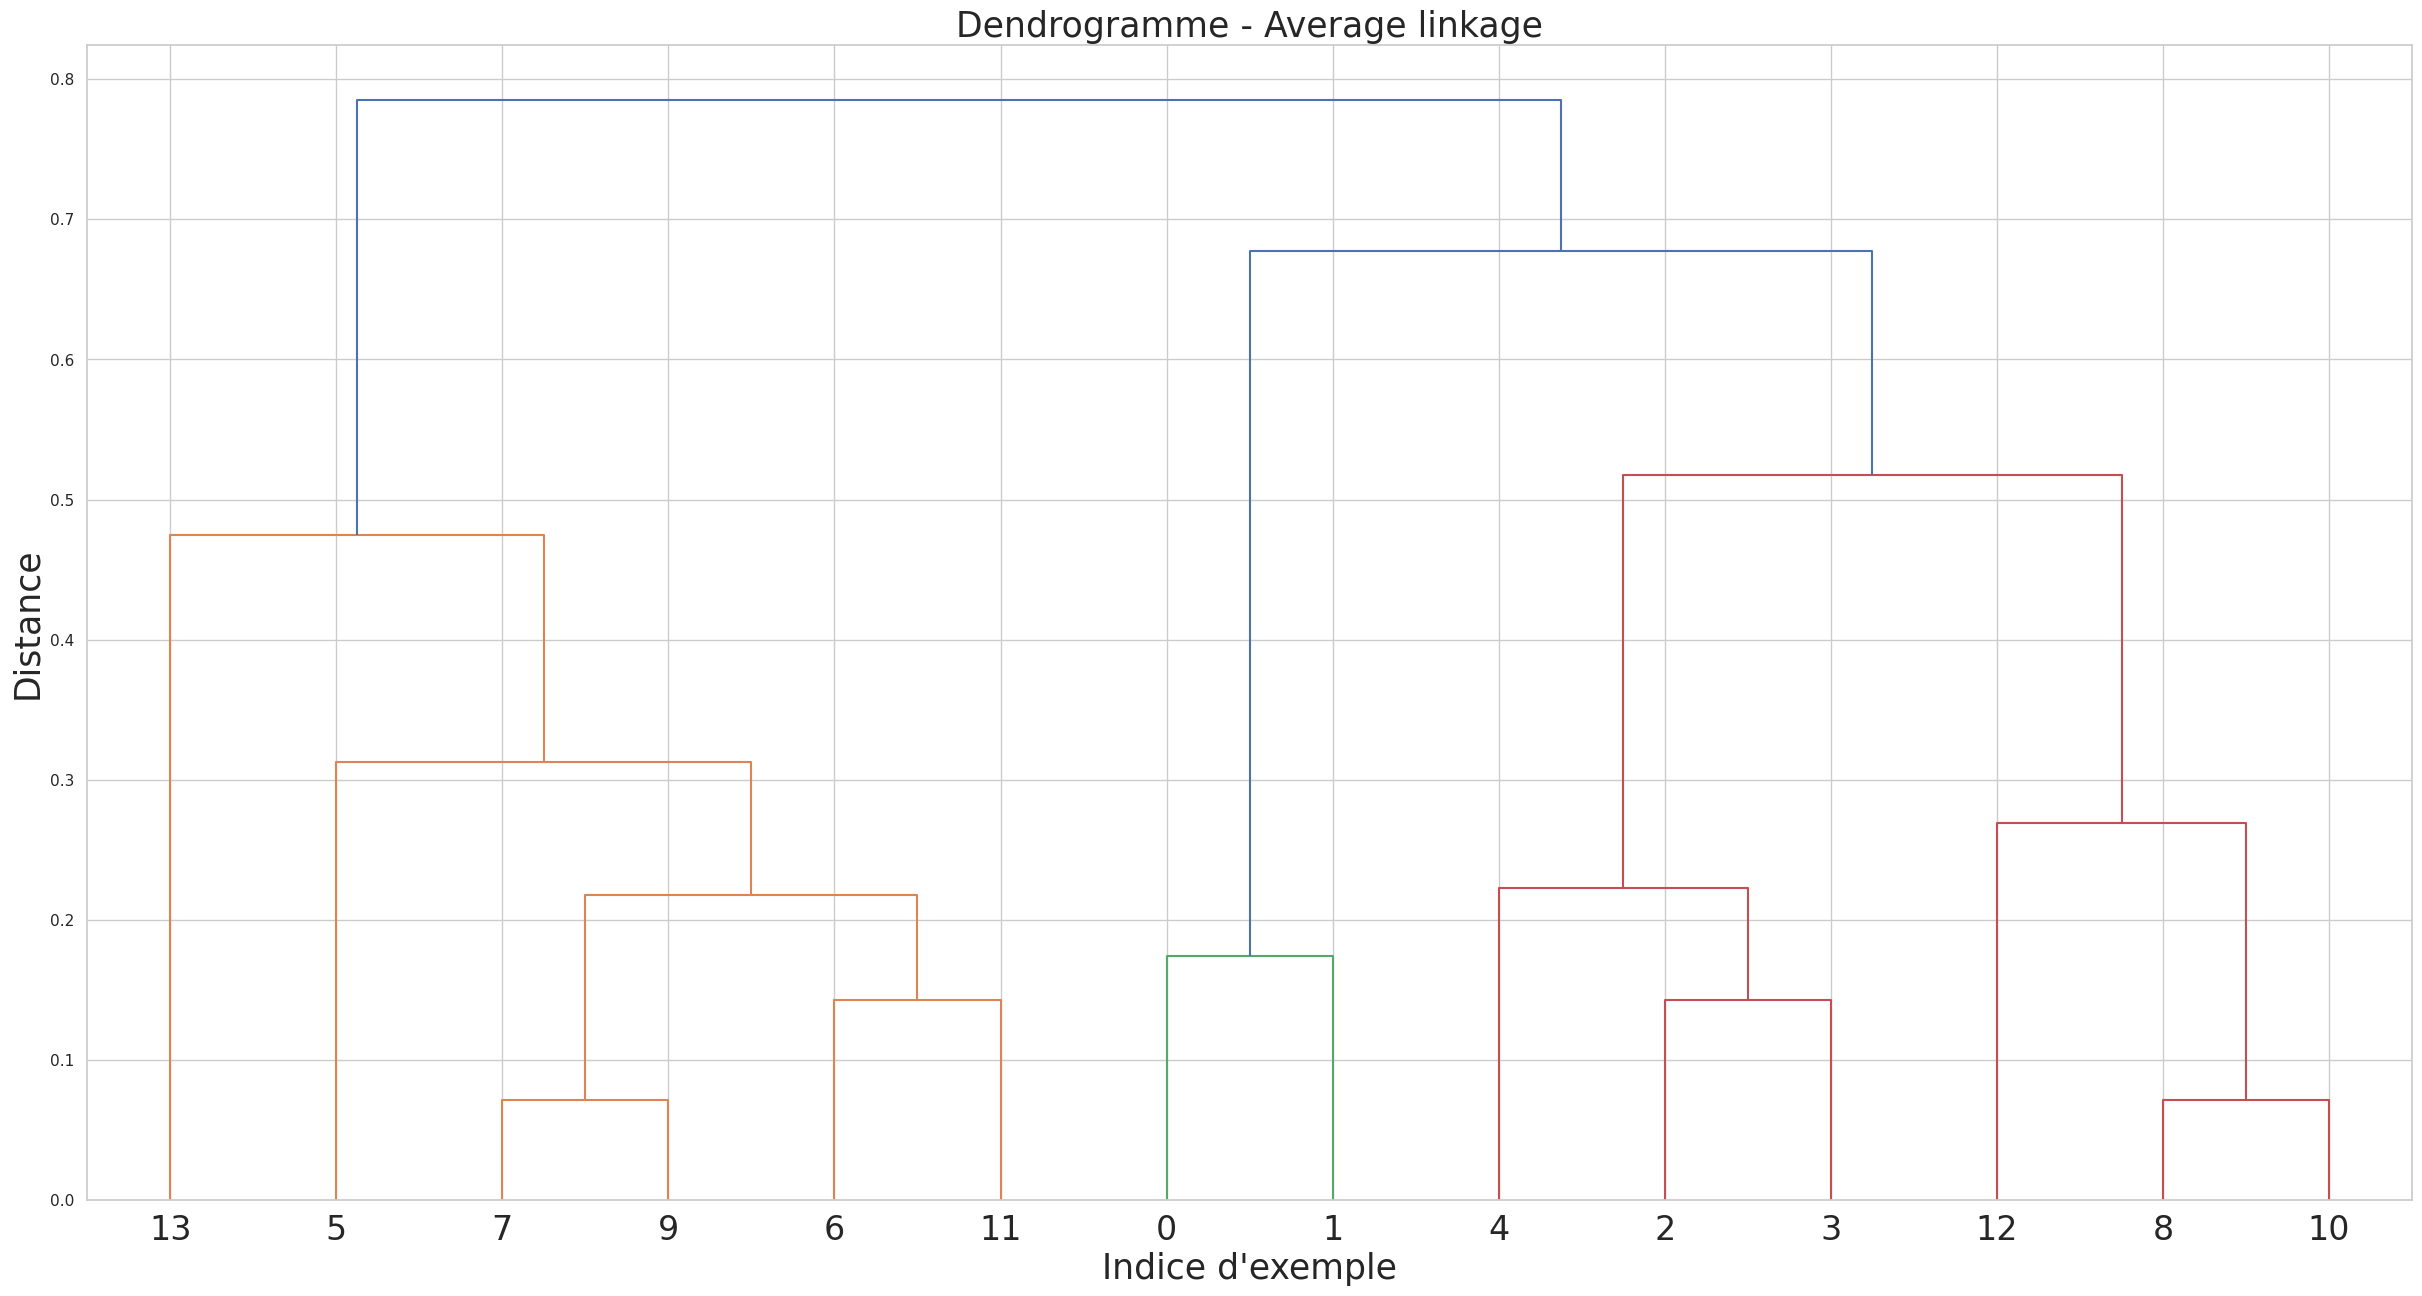

array([[ 8.        , 10.        ,  0.07142857,  2.        ],
       [ 7.        ,  9.        ,  0.07142857,  2.        ],
       [ 2.        ,  3.        ,  0.14285714,  2.        ],
       [ 6.        , 11.        ,  0.14285714,  2.        ],
       [ 0.        ,  1.        ,  0.17437937,  2.        ],
       [15.        , 17.        ,  0.21763139,  4.        ],
       [ 4.        , 16.        ,  0.22289036,  3.        ],
       [12.        , 14.        ,  0.26944954,  3.        ],
       [ 5.        , 19.        ,  0.31302706,  5.        ],
       [13.        , 22.        ,  0.4745492 ,  6.        ],
       [20.        , 21.        ,  0.51755754,  6.        ],
       [18.        , 24.        ,  0.67703247,  8.        ],
       [23.        , 25.        ,  0.78496319, 14.        ]])

In [95]:
CHA(data_2D_norm,linkage='average',dendrogramme=True)

### Une base pour voir les différences

Etudier les différences de résultats obtenus avec chacune des approches de linkage sur la base suivante.

In [ ]:
data_2D_diff = normalisation(pd.read_csv("data/base-2D-diff.csv"))

In [ ]:
data_2D_diff

In [ ]:
# X1_values =  # A COMPLETER
# X2_values = # A COMPLETER


In [ ]:
print("Il y a", len(data_2D_diff), "exemples dans la base.")

plt.scatter(X1_values,X2_values)


In [ ]:
res_centroid = CHA(data_2D_diff,linkage='centroid',dendrogramme=True)

In [ ]:
res_complete = CHA(data_2D_diff,linkage='complete',dendrogramme=True)

In [ ]:
res_simple = CHA(data_2D_diff,linkage='simple',dendrogramme=True)

In [ ]:
res_average = CHA(data_2D_diff,linkage='average',dendrogramme=True)

## Ajout des fonctions dans la librairie `iads`

<font size="+1" color="RED"><b>[Q]</b></font> Ajouter les fonctions de clustering dans votre librairie `iads`. Pour cela, créer un nouveau fichier de nom `Clustering.py` dans votre répertoire `iads`. 
Utiliser les premières lignes du fichier `Classifiers.py` pour débuter votre fichier `Clustering.py`, puis rajouter dans ce fichier les fonctions de clustering hiérarchique (tous linkages) de ce notebook, ainsi que les fonctions qu'elles utilisent.

## Phase 2 : application à des données réelles

### Données: traitement des déchets de la ville de Paris

Pour tester votre implémentation, vous allez utiliser les données publiques de traitement des déchets de la ville de Paris qui sont fournies dans le fichier `base-Paris.csv`.

**Attention**: il faut préparer cette base afin de pouvoir appliquer l'algorithme de clustering: en particulier, certaines colonnes (Granularité, Total...) ne sont pas à utilisables dans le calcul des distances, il faut donc les éliminer. Il faut aussi prévoir de conserver le nom de l'arrondissement afin de pouvoir à la fin analyser le résultat du clustering.


<font size="+1" color="RED"><b>[Q]</b></font> Etudier cette base et les clusters qui peuvent être mis en évidence.


In [ ]:
data_Paris = # A COMPLETER

In [ ]:
data_Paris

<font size="+1" color="RED"><b>[Q]</b></font> Préparer un rapport d'analyse (c'est-à-dire, compléter votre notebook en rajoutant à la suite tout un ensemble d'expérimentations et de résultats obtenus sur la base) réalisé sur cette base qui mette en évidence les clusters existants à différents niveaux de distance, et en utilisant différentes distances.
